# Mask R-CNN for Lunar Instance Segmentation 

**Author:** Amirmohammad Saiedi Saber · *Moon Feature Recognition — Computational Physics 2026*


In [1]:
# Environment setup:
# imports the required libraries, sets cache folders,

from pathlib import Path
import os, json, math, random, time, re
from dataclasses import dataclass, asdict, field
from typing import Optional

os.environ.setdefault('MPLCONFIGDIR', '/tmp/moon_matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader

# fixes random seeds for reproducibility, and selects the device
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True   
    
# for training. If CUDA/GPU is available, the model uses it;
# otherwise, it runs on CPU.

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch       :', torch.__version__)
print('Torchvision :', torchvision.__version__)
print('Device      :', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU         :', torch.cuda.get_device_name(0))


Torch       : 2.12.0
Torchvision : 0.27.0
Device      : cpu


## 1. Configurations(Setting)

In [2]:
#  Single source of truth for all settings
@dataclass
class Config:
    # instance-target preparation
    # Channel -> class map
    #   None -> AUTO: section 3b keeps the classes labelled in >= min_tiles_per_class tiles,
    #           so training on the FREQUENT, worthwhile features (not the near-empty ones).
    #   dict -> pin exact classes
    instance_channels: Optional[dict] = field(default_factory=lambda: {'impact_crater': 0, 'pit_skylight': 1, 'wrinkle_ridge': 2, 'lobate_scarp': 3})
    min_tiles_per_class: int = 200       # auto-keep a channel only if labelled in >= this many tiles
    channel_names: Optional[list] = field(default_factory=lambda: [
        'impact_crater', 'pit_skylight', 'wrinkle_ridge', 'lobate_scarp',
        'irregular_mare_patch', 'apollo_site', 'candidate_rille'])   # README channel order
    channel_scan_samples: Optional[int] = None  
    min_instance_area: int = 30          # drop specks (pixels)
    max_instance_area: int = 6000        # drop merged/blob masks -> keep separable objects
    max_channel_fraction: float = 0.20   # per tile: skip a channel if it covers > this (dense -> can't be split)
    max_instances_per_tile: int = 100
    connectivity: int = 2                # 2 = 8-connectivity for connected components

    #  dataset, split 
    max_samples: Optional[int] = None    # None -> use EVERY tile that has >=1 instance
    val_fraction: float = 0.20
    spatial_split: bool = True           # reduce leakage between neighbouring tiles
    augment: bool = True

    # model
    pretrained: bool = True              # COCO transfer learning
    trainable_backbone_layers: int = 3   # lower layers be more frozen, only some higher layers be fine_tuned
    anchor_sizes: tuple = (8, 16, 32, 64, 128)   # one size per FPN level (lunar scale)
    anchor_ratios: tuple = (0.5, 1.0, 2.0)       # tall/narrow, square, wide boxes
    box_score_thresh: float = 0.05       # inference: keep low for metrics
    box_nms_thresh: float = 0.50         # remove too much overlap boxes
    detections_per_img: int = 200        # max detections per tile
    # custom deep heads (the architecture contribution)
    use_custom_heads: bool = True        # True -> custom deep heads on a pretrained backbone
    mask_head_blocks: int = 4            # residual blocks in the custom mask head
    mask_head_hidden: int = 256          # channels in the custom mask head
    box_head_depth: int = 4              # fully-connected layers in the custom box head
    box_head_hidden: int = 1024          # width of the custom box-head MLP
    head_dropout: float = 0.05           # dropout inside the conv head
    box_head_dropout: float = 0.10       # dropout inside the box-head MLP

    # training
    num_epochs: int = 20
    batch_size: int = 8
    num_workers: int = 0                 # num of using cpu, parallel data loading
    lr: float = 2e-4                     # base LR
    backbone_lr_mult: float = 0.1        # pretrained backbone+RPN trains at lr * this
    weight_decay: float = 1e-4           # regularization
    warmup_epochs: int = 1               # stabilize early training
    grad_clip: float = 5.0
    use_amp: bool = True                 # mixed precision (GPU only; auto no-op on CPU)
    resume: bool = True                  # resume from last_model.pth if it exists

    # evaluation / visualisation
    eval_iou_thresh: float = 0.50        # IoU threshold for TruePositive matching + AP@0.5
    score_thresh_eval: float = 0.50      # confidence score threshold for visualization
    mask_thresh: float = 0.50            # binarise predicted soft masks
    eval_max_batches: Optional[int] = 200  # cap per-epoch val (None=all); final eval uses all

    # output
    output_dir: str = 'amir_rcnn_outputs'
    max_pred_export: Optional[int] = 500   # cap saved per-tile predictions 

CFG = Config()

def resolve_output_dir(cfg=CFG):
    cwd = Path.cwd().expanduser()
    raw = Path(cfg.output_dir).expanduser()
    candidates = []
    if cwd.name == cfg.output_dir:
        candidates.append(cwd)
    if raw.is_absolute():
        candidates.append(raw)
    candidates.extend([
        Path.home() / 'Desktop' / cfg.output_dir,
        cwd / cfg.output_dir,
        cwd.parent / cfg.output_dir,
    ])

    seen = []
    for p in candidates:
        p = p.expanduser()
        if p not in seen:
            seen.append(p)

    for p in seen:
        if (p / 'best_model.pth').exists() or (p / 'last_model.pth').exists() or (p / 'training_history.csv').exists():
            return p
    return seen[0]

OUTPUT_DIR = resolve_output_dir(CFG)
(OUTPUT_DIR / 'predictions').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)

print('Output dir :', OUTPUT_DIR.resolve())


Output dir : /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs


## 2. Shared utilities (image normalisation + instance plotting)


In [3]:

#  Helpers 


def normalize_image_chw(image):
    # Return image as float32 C x H x W in [0, 1] with exactly 3 channels.
    image = np.asarray(image, dtype=np.float32)
    if image.ndim == 2:
        image = image[None]
    if image.shape[-1] <= 4 and image.shape[0] > 4:   # channel-last -> channel-first
        image = np.moveaxis(image, -1, 0)
    if image.shape[0] == 1:
        image = np.repeat(image, 3, axis=0)
    if image.shape[0] > 3:
        image = image[:3]
    if image.max() > 1.5:                              # 0..255 -> 0..1
        image = image / 255.0
    return np.clip(image, 0.0, 1.0).astype(np.float32)

def _to_numpy(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)

_CMAP = plt.get_cmap('tab10')                       # distinct colours for up to 10 classes
def class_color(label):
    return _CMAP((int(label) - 1) % 10)[:3]

def plot_instances(image_chw, boxes, masks=None, labels=None, scores=None,
                   title='instances', score_threshold=0.0, ax=None):
    # Draw boxes (+ optional masks/labels/scores) over a lunar tile.
    image_hwc = np.moveaxis(normalize_image_chw(image_chw), 0, -1)
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_hwc); ax.set_title(title); ax.axis('off')

    boxes = _to_numpy(boxes) if boxes is not None else np.zeros((0, 4))
    labels = _to_numpy(labels) if labels is not None else None
    scores = _to_numpy(scores) if scores is not None else None
    if masks is not None:
        masks = _to_numpy(masks)
        if masks.ndim == 4:
            masks = masks[:, 0]

    for i, box in enumerate(boxes):
        if scores is not None and scores[i] < score_threshold:
            continue
        lab = int(labels[i]) if (labels is not None and i < len(labels)) else 1
        color = class_color(lab)
        if masks is not None and i < len(masks):
            m = masks[i] >= 0.5
            overlay = np.zeros((m.shape[0], m.shape[1], 4), dtype=np.float32)
            overlay[m] = (color[0], color[1], color[2], 0.45)
            ax.imshow(overlay)
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=1.5, edgecolor=color))
        txt = LABEL_TO_NAME.get(lab, str(lab))
        if scores is not None:
            txt += f' {scores[i]:.2f}'
        ax.text(x1, max(0, y1 - 2), txt, color=color, fontsize=7, weight='bold')
    if own:
        plt.tight_layout(); plt.show()

def normalize_image_chw(image):  # normalize_image_chw() standardizes image format for the model.
    # Return image as float32 C x H x W in [0, 1] with exactly 3 channels.
    image = np.asarray(image, dtype=np.float32)  # convert image to array
    if image.ndim == 2:
        image = image[None]
    if image.shape[-1] <= 4 and image.shape[0] > 4:   # channel-last -> channel-first
        image = np.moveaxis(image, -1, 0)
    if image.shape[0] == 1:   # if it grayscale, repeat it 3 times because ResNet50 pretrained on RGB three color_ channels
        image = np.repeat(image, 3, axis=0)
    if image.shape[0] > 3:           # more than 3 channels, don't count it
        image = image[:3]
    if image.max() > 1.5:                              # 0..255 -> 0..1 normalization
        image = image / 255.0
    return np.clip(image, 0.0, 1.0).astype(np.float32)

def _to_numpy(x): # _to_numpy() converts tensors to NumPy arrays for plotting.
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)

_CMAP = plt.get_cmap('tab10')                       # distinct colours for up to 10 classes
def class_color(label):      # class_color() assigns a color to each class label.
    return _CMAP((int(label) - 1) % 10)[:3]

def plot_instances(image_chw, boxes, masks=None, labels=None, scores=None, # plot_instances() visualizes ground-truth or predicted instances
                   title='instances', score_threshold=0.0, ax=None): # by drawing masks, bounding boxes, labels, and confidence scores.
    # Draw boxes over a lunar tile.
    image_hwc = np.moveaxis(normalize_image_chw(image_chw), 0, -1)
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_hwc); ax.set_title(title); ax.axis('off')

    boxes = _to_numpy(boxes) if boxes is not None else np.zeros((0, 4))
    labels = _to_numpy(labels) if labels is not None else None
    scores = _to_numpy(scores) if scores is not None else None
    if masks is not None:
        masks = _to_numpy(masks)
        if masks.ndim == 4:
            masks = masks[:, 0]

    for i, box in enumerate(boxes):
        if scores is not None and scores[i] < score_threshold:
            continue
        lab = int(labels[i]) if (labels is not None and i < len(labels)) else 1
        if LABEL_TO_NAME.get(lab) == 'wrinkle_ridge':
            continue
        color = class_color(lab)
        if masks is not None and i < len(masks):
            m = masks[i] >= 0.5
            overlay = np.zeros((m.shape[0], m.shape[1], 4), dtype=np.float32)
            overlay[m] = (color[0], color[1], color[2], 0.45)
            ax.imshow(overlay)
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=1.5, edgecolor=color)) # bounding box rectangle
        txt = LABEL_TO_NAME.get(lab, str(lab))
        if scores is not None:
            txt += f' {scores[i]:.2f}'
        ax.text(x1, max(0, y1 - 2), txt, color=color, fontsize=7, weight='bold')
    if own:
        plt.tight_layout(); plt.show()


## 3.  dataset



In [4]:
#  Find the Marius Hills tiles + index.csv (Metadata about dataset tiles)

MR_ROOT_CANDIDATES = [
    Path('/home/LCP/MAPD-B/MOON/2026/code/Computational-Physics-2026/local_data/data/MR'),
    Path('/home/LCP/MAPD-B/MOON/2026/code/Computational-Physics-2026/data/MR'),
    Path.home() / 'Downloads' / 'data' / 'MR',
    Path.home() / 'Computational-Physics-2026' / 'local_data' / 'data' / 'MR',
    Path.cwd() / 'data' / 'MR',
    Path.cwd().parent / 'data' / 'MR',
]

def find_mr_root(candidates):
    checked = []
    for root in candidates:
        root = Path(root).expanduser()
        checked.append(root)
        index_path = root / 'tiles' / 'index.csv'
        npz_dir = root / 'data' / 'processed' / 'tiles' / 'marius_hills'
        if index_path.exists() and npz_dir.exists():
            return root
    checked_text = chr(10).join(str(p) for p in checked)
    raise FileNotFoundError('Could not find MR dataset. Checked:' + chr(10) + checked_text)

MR_ROOT = find_mr_root(MR_ROOT_CANDIDATES)
INDEX_PATH = MR_ROOT / 'tiles' / 'index.csv'
NPZ_DIR = MR_ROOT / 'data' / 'processed' / 'tiles' / 'marius_hills'

index_df = pd.read_csv(INDEX_PATH)
npz_files = sorted(NPZ_DIR.glob('*.npz'))
if not npz_files:
    raise FileNotFoundError(f'No .npz tiles found in {NPZ_DIR}')

# tile side length (assumed square) used by the model transform + metrics
TILE_SIZE = int(normalize_image_chw(np.load(npz_files[0])['image']).shape[-1])

print('MR_ROOT   :', MR_ROOT)
print('INDEX_PATH:', INDEX_PATH)
print('NPZ_DIR   :', NPZ_DIR)
print('NPZ tiles :', len(npz_files))
print('Tile size :', TILE_SIZE, 'px')
display(index_df.head())


MR_ROOT   : /Users/amirmohammadsaiedisaber/Downloads/data/MR
INDEX_PATH: /Users/amirmohammadsaiedisaber/Downloads/data/MR/tiles/index.csv
NPZ_DIR   : /Users/amirmohammadsaiedisaber/Downloads/data/MR/data/processed/tiles/marius_hills
NPZ tiles : 15935
Tile size : 256 px


,aoi,tile_path,row,col,positive_pixels
0,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,0,1271
1,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,128,1247
2,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,256,916
3,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,384,947
4,marius_hills,data/processed/tiles/marius_hills/marius_hills...,0,512,998


## 3b. Scan every tile, then keep the frequent classes

This scans the whole dataset and counts how many tiles contain labels in each mask channel.
It then **keeps the classes that are frequent enough to be worth training** — any channel
labelled in at least `CFG.min_tiles_per_class` tiles — and drops the near-empty ones. Lower
that number to include rarer classes, raise it to focus on the most common. The dense
`impact_crater` channel is kept but only contributes instances from tiles where it is sparse
enough to separate. 


In [5]:
# Full-dataset channel scan + automatic class selection

_m0 = np.load(npz_files[0])['mask']
N_MASK_CHANNELS = int(_m0.shape[0]) if _m0.ndim == 3 else 1

scan_files = npz_files if CFG.channel_scan_samples is None else npz_files[:CFG.channel_scan_samples]
tiles_with_px = {c: 0 for c in range(N_MASK_CHANNELS)}
total_px      = {c: 0 for c in range(N_MASK_CHANNELS)}
frac_sum      = {c: 0.0 for c in range(N_MASK_CHANNELS)}

print(f'Scanning {len(scan_files)} tiles for labelled channels (this can take a few minutes)...')
for f in scan_files:
    with np.load(f) as t:
        m = t['mask']
        if m.ndim == 2:
            m = m[None]
        area = m.shape[-1] * m.shape[-2]
        for c in range(m.shape[0]):
            pos = int((m[c] > 0).sum())
            if pos > 0:
                tiles_with_px[c] += 1
                total_px[c] += pos
            frac_sum[c] += pos / area

n = max(1, len(scan_files))
def _name(c):
    names = CFG.channel_names or []
    return names[c] if c < len(names) else f'class_{c}'

print('Channel scan result (selection by frequency >= %d tiles):' % CFG.min_tiles_per_class)
for c in range(N_MASK_CHANNELS):
    meanfrac = frac_sum[c] / n
    dense = '  [dense semantic -> sparse tiles only]' if meanfrac >= CFG.max_channel_fraction else ''
    keep = 'KEEP' if tiles_with_px[c] >= CFG.min_tiles_per_class else 'drop(rare)'
    print(f'  ch {c} {_name(c):22s}: {tiles_with_px[c]:6d} tiles | mean cov {meanfrac:.3f} | {total_px[c]:>12,} px  -> {keep}{dense}')

# keep channels labelled in enough tiles to be worth training
DATA_CHANNELS = [c for c in range(N_MASK_CHANNELS) if tiles_with_px[c] >= CFG.min_tiles_per_class]

if CFG.instance_channels:                       # explicit override wins
    INSTANCE_CHANNELS = dict(CFG.instance_channels)
    print('Using explicit CFG.instance_channels:', INSTANCE_CHANNELS)
else:                                           # auto-pick the frequent channels
    INSTANCE_CHANNELS = {_name(c): c for c in DATA_CHANNELS}
    dropped = [_name(c) for c in range(N_MASK_CHANNELS) if c not in DATA_CHANNELS]
    print(f'Auto-selected (>= {CFG.min_tiles_per_class} tiles):', INSTANCE_CHANNELS)
    if dropped:
        print('Dropped (too rare):', dropped)

if not INSTANCE_CHANNELS:
    raise ValueError('No usable channels found - check the mask data or CFG.max_channel_fraction.')

CLASS_NAMES = ['background'] + list(INSTANCE_CHANNELS.keys())
NUM_CLASSES = len(CLASS_NAMES)
CHANNEL_TO_LABEL = {ch: i for i, ch in enumerate(INSTANCE_CHANNELS.values(), start=1)}
LABEL_TO_NAME = {i: name for i, name in enumerate(CLASS_NAMES)}
print('Instance classes :', CLASS_NAMES, f'(NUM_CLASSES={NUM_CLASSES})')
print('Channel -> label  :', CHANNEL_TO_LABEL)


Scanning 15935 tiles for labelled channels (this can take a few minutes)...
Channel scan result (selection by frequency >= 200 tiles):
  ch 0 impact_crater         :  15935 tiles | mean cov 0.821 |  857,667,704 px  -> KEEP  [dense semantic -> sparse tiles only]
  ch 1 pit_skylight          :    246 tiles | mean cov 0.000 |       43,748 px  -> KEEP
  ch 2 wrinkle_ridge         :   2993 tiles | mean cov 0.006 |    6,657,044 px  -> KEEP
  ch 3 lobate_scarp          :    272 tiles | mean cov 0.000 |      139,990 px  -> KEEP
  ch 4 irregular_mare_patch  :    103 tiles | mean cov 0.000 |       20,676 px  -> drop(rare)
  ch 5 apollo_site           :    175 tiles | mean cov 0.000 |       15,556 px  -> drop(rare)
  ch 6 candidate_rille       :     20 tiles | mean cov 0.000 |       10,080 px  -> drop(rare)
Using explicit CFG.instance_channels: {'impact_crater': 0, 'pit_skylight': 1, 'wrinkle_ridge': 2, 'lobate_scarp': 3}
Instance classes : ['background', 'impact_crater', 'pit_skylight', 'wrinkle

## 4. Inspect a tile and audit the mask channels

The lecture warns that some mask channels can encode coverage/background rather than real
objects. Before training I looked at one tile and at the per-channel positive-pixel fraction
across many tiles, so the channel choice in `CFG.instance_channels` is justified. 	

“This cell loads one NPZ tile and inspects its image and mask arrays. The image has shape 3 × 256 × 256, so it has three input channels and a 256-pixel tile size. The mask has shape 7 × 256 × 256, meaning there are seven annotation channels. I visualize the lunar tile, one grayscale image channel, and then each mask channel separately. This helps me check which channels correspond to sparse, countable lunar objects and which channels may be dense coverage or background-like masks. This step is necessary before converting semantic mask channels into instance masks for Mask R-CNN.”

image: (3, 256, 256) float32 | mask: (7, 256, 256) uint8


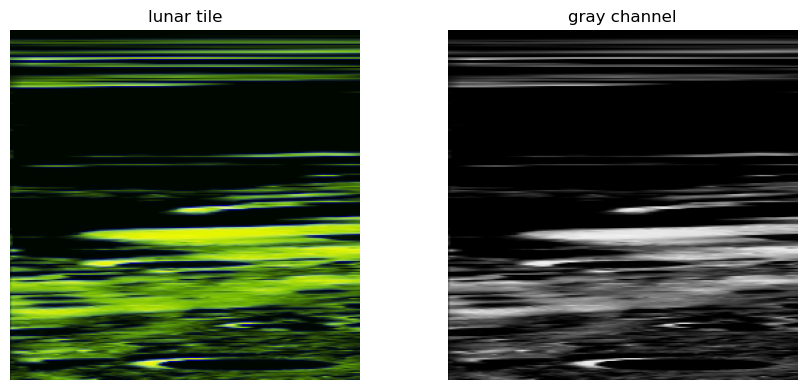

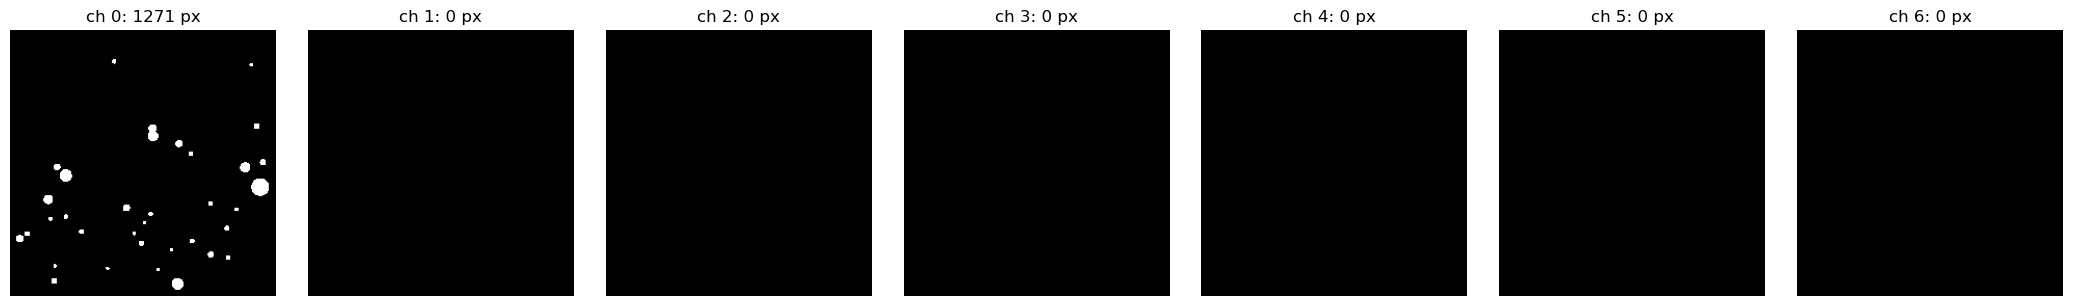

In [6]:
# Visualise one tile: image, gray channel, mask channels

sample = np.load(npz_files[0])
image, mask = sample['image'], sample['mask']
print('image:', image.shape, image.dtype, '| mask:', mask.shape, mask.dtype)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(np.moveaxis(normalize_image_chw(image), 0, -1)); axes[0].set_title('lunar tile'); axes[0].axis('off')
axes[1].imshow(normalize_image_chw(image)[0], cmap='gray'); axes[1].set_title('gray channel'); axes[1].axis('off')
plt.tight_layout(); plt.show()

mask3 = mask if mask.ndim == 3 else mask[None]
n_ch = mask3.shape[0]
fig, axes = plt.subplots(1, n_ch, figsize=(3 * n_ch, 3))
axes = np.atleast_1d(axes)
for ch in range(n_ch):
    axes[ch].imshow(mask3[ch], cmap='gray')
    axes[ch].set_title(f'ch {ch}: {int(mask3[ch].sum())} px'); axes[ch].axis('off')
plt.tight_layout(); plt.show()


In [7]:

# finding and using frequent and worthy channels for training 
try:
    from skimage.measure import label as _sk_label
except Exception:
    _sk_label = None

sample_paths = npz_files[:min(150, len(npz_files))]
stats = {}
for p in sample_paths:
    with np.load(p) as t:
        m = t['mask']
        if m.ndim == 2:
            m = m[None]
        for ch in range(m.shape[0]):
            b = m[ch] > 0
            nblob = int(_sk_label(b).max()) if (_sk_label is not None and b.any()) else 0
            s = stats.setdefault(ch, {'frac': [], 'blobs': []})
            s['frac'].append(float(b.mean())); s['blobs'].append(nblob)

print(f'Per-channel audit over {len(sample_paths)} tiles '
      '(coverage = mean positive fraction, blobs = mean connected components):')
for ch in sorted(stats):
    fr = float(np.mean(stats[ch]['frac'])); nb = float(np.mean(stats[ch]['blobs']))
    if fr >= CFG.max_channel_fraction:
        role = 'coverage/background'
    elif nb >= 1.5:
        role = 'object-like (crater/pit/boulder)'
    else:
        role = 'continuous/sparse (ridge/rille?)'
    used = 'USED' if ch in CHANNEL_TO_LABEL else 'unused'
    skip = '  [skipped per-tile: mostly-on]' if fr > CFG.max_channel_fraction else ''
    print(f'  ch {ch}: coverage={fr:.3f}  blobs~{nb:5.1f}  -> {role:34s} [{used}]{skip}')

print('\nMany small blobs + low coverage  = good instance target (Mask R-CNN).')
print('Few big blobs or high coverage    = continuous/coverage -> really U-Net .')


Per-channel audit over 150 tiles (coverage = mean positive fraction, blobs = mean connected components):
  ch 0: coverage=0.043  blobs~  0.0  -> continuous/sparse (ridge/rille?)   [USED]
  ch 1: coverage=0.000  blobs~  0.0  -> continuous/sparse (ridge/rille?)   [USED]
  ch 2: coverage=0.000  blobs~  0.0  -> continuous/sparse (ridge/rille?)   [USED]
  ch 3: coverage=0.000  blobs~  0.0  -> continuous/sparse (ridge/rille?)   [USED]
  ch 4: coverage=0.000  blobs~  0.0  -> continuous/sparse (ridge/rille?)   [unused]
  ch 5: coverage=0.000  blobs~  0.0  -> continuous/sparse (ridge/rille?)   [unused]
  ch 6: coverage=0.000  blobs~  0.0  -> continuous/sparse (ridge/rille?)   [unused]

Many small blobs + low coverage  = good instance target (Mask R-CNN).
Few big blobs or high coverage    = continuous/coverage -> really U-Net .


## 4. Prepare instance targets (semantic mask → objects)

threshold each object channel,
run **connected-component labelling**, filter by area/shape, and emit
`boxes, labels, masks, area` per object instance.


instances in sample tile: 10 | labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


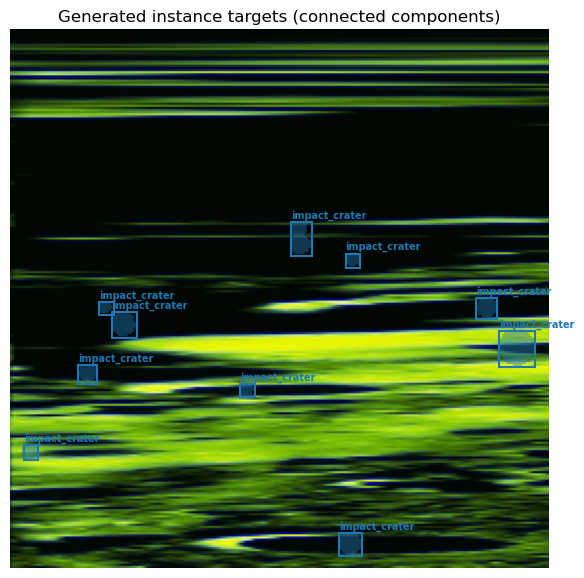

In [8]:
# Connected components -> instance targets
# Convert semantic masks to Mask R-CNN instance targets:
# The dataset provides multi-channel masks, where each channel corresponds
# to a lunar feature class. Mask R-CNN needs individual object instances,
# so we apply connected-component labeling to each selected channel.
# Each connected component becomes one object with a bounding box, label,
# binary mask, and area. Very small, very large, or thin components are
# filtered out to reduce noisy training targets.
try:
    from skimage.measure import label as sk_label
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False

def _connected_components(binary, connectivity=2): 
    if _HAS_SKIMAGE:
        lab = sk_label(binary.astype(bool), connectivity=connectivity)
        return lab, int(lab.max())
    # pure-numpy flood-fill fallback (8-connectivity)
    binary = binary.astype(bool); h, w = binary.shape
    lab = np.zeros((h, w), np.int32); cid = 0
    nb = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)] # 8 neighbouring directions
    for y0, x0 in np.argwhere(binary):
        if lab[y0, x0]:
            continue
        cid += 1; lab[y0, x0] = cid; stack = [(int(y0), int(x0))]
        while stack:
            y, x = stack.pop()
            for dy, dx in nb:
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w and binary[ny, nx] and not lab[ny, nx]:
                    lab[ny, nx] = cid; stack.append((ny, nx))
    return lab, cid

def extract_instances(mask, cfg=CFG):
    # Multi-channel semantic mask -> dict(boxes, labels, masks, areas, channels).
    mask = np.asarray(mask)
    if mask.ndim == 2:
        mask = mask[None]
    if mask.shape[-1] <= 16 and mask.shape[0] > 16:   # channel-last -> channel-first
        mask = np.moveaxis(mask, -1, 0)
    _, H, W = mask.shape
    boxes, labels, masks, areas, channels = [], [], [], [], []

    for ch, label_id in CHANNEL_TO_LABEL.items():
        if ch >= mask.shape[0]:
            continue
        binary = mask[ch] > 0
        frac = binary.mean()
        if frac == 0 or frac > cfg.max_channel_fraction:   # empty or coverage-like channel
            continue
        comp, n = _connected_components(binary, cfg.connectivity)
        for cid in range(1, n + 1):
            obj = comp == cid
            area = int(obj.sum())
            if area < cfg.min_instance_area or area > cfg.max_instance_area:
                continue
            ys, xs = np.where(obj)
            x1, x2 = int(xs.min()), int(xs.max()) + 1
            y1, y2 = int(ys.min()), int(ys.max()) + 1
            if (x2 - x1) < 3 or (y2 - y1) < 3:             # drop slivers
                continue
            boxes.append([x1, y1, x2, y2]); labels.append(label_id)
            masks.append(obj.astype(np.uint8)); areas.append(area); channels.append(ch)

    if not boxes:
        return dict(boxes=np.zeros((0, 4), np.float32), labels=np.zeros((0,), np.int64),
                    masks=np.zeros((0, H, W), np.uint8), areas=np.zeros((0,), np.float32),
                    channels=np.zeros((0,), np.int64))
    order = np.argsort(areas)[::-1][:cfg.max_instances_per_tile]
    return dict(boxes=np.asarray(boxes, np.float32)[order],
                labels=np.asarray(labels, np.int64)[order],
                masks=np.asarray(masks, np.uint8)[order],
                areas=np.asarray(areas, np.float32)[order],
                channels=np.asarray(channels, np.int64)[order])

inst = extract_instances(mask)
print('instances in sample tile:', len(inst['boxes']),
      '| labels:', inst['labels'].tolist())
plot_instances(image, inst['boxes'], inst['masks'], inst['labels'],
               title='Generated instance targets (connected components)')


## 5. Dataset and augmentation

Returns exactly the dictionary torchvision detection models expect:
`image: Tensor[C,H,W]` and `target: {boxes, labels, masks, image_id, area, iscrowd}`.
Geometric augmentations are applied to **both** image and mask; brightness/contrast jitter
is image-only .


In [9]:
# Dataset + collate

class MoonInstanceDataset(Dataset):
    def __init__(self, files, cfg=CFG, augment=False, keep_empty=True):
        self.cfg = cfg; self.augment = augment
        self.files = [Path(f) for f in files]
        if not keep_empty:
            self.files = [f for f in self.files
                          if len(extract_instances(np.load(f)['mask'], cfg)['boxes']) > 0]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        with np.load(self.files[idx]) as t:
            image = normalize_image_chw(t['image'])
            mask = np.asarray(t['mask'])
        if self.augment:
            if random.random() < 0.5:                       # horizontal flip
                image = image[:, :, ::-1].copy(); mask = mask[..., ::-1].copy()
            if random.random() < 0.5:                       # vertical flip
                image = image[:, ::-1, :].copy(); mask = mask[..., ::-1, :].copy()
            if random.random() < 0.3:                       # brightness/contrast (image only)
                gain = 0.9 + 0.2 * random.random()
                bias = -0.05 + 0.1 * random.random()
                image = np.clip(image * gain + bias, 0.0, 1.0).astype(np.float32)
        inst = extract_instances(mask, self.cfg)
        image_t = torch.as_tensor(image, dtype=torch.float32)
        target = {
            'boxes':    torch.as_tensor(inst['boxes'], dtype=torch.float32),
            'labels':   torch.as_tensor(inst['labels'], dtype=torch.int64),
            'masks':    torch.as_tensor(inst['masks'], dtype=torch.uint8),
            'image_id': torch.tensor([idx], dtype=torch.int64),
            'area':     torch.as_tensor(inst['areas'], dtype=torch.float32),
            'iscrowd':  torch.zeros((len(inst['labels']),), dtype=torch.int64),
        }
        return image_t, target

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


## 6. Spatial train / validation split

Neighbouring tiles share morphology and illumination, so a random split leaks information.
By default I hold out a spatial band (the right-most tile columns, read from the
`rXXXXX_cXXXXX` filename) and fall back to a random split if that is not possible.


tiles with >=1 instance: 4198
train tiles: 3345 | val tiles: 853 | spatial_split=True
image: (3, 256, 256) | boxes: (12, 4) | masks: (12, 256, 256)


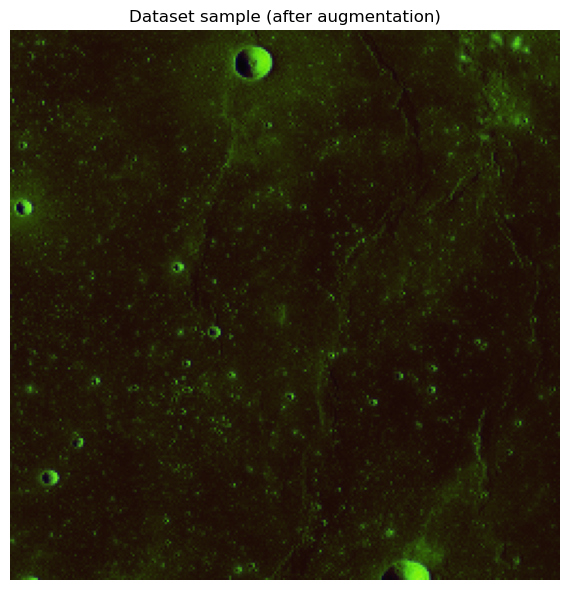

In [10]:
#  Build train/val file lists and DataLoaders

_required = ['npz_files', 'extract_instances', 'MoonInstanceDataset', 'CHANNEL_TO_LABEL']
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        'Run the setup cells first: imports/config, helpers, dataset location, channel scan, '
        'instance extraction, and dataset class. Missing: ' + ', '.join(_missing)
    )

_RC = re.compile(r'r(\d+)_c(\d+)')
def tile_rowcol(path):
    m = _RC.search(Path(path).name)
    return (int(m.group(1)), int(m.group(2))) if m else (0, 0)

rng = np.random.default_rng(SEED)
shuffled = list(npz_files); rng.shuffle(shuffled)

# keep only tiles that contain at least one instance target
candidate_files = []
for f in shuffled:
    if len(extract_instances(np.load(f)['mask'], CFG)['boxes']) > 0:
        candidate_files.append(f)
        if CFG.max_samples and len(candidate_files) >= CFG.max_samples:
            break
if not candidate_files:
    raise RuntimeError('No tiles with instance targets were found. Check CFG.instance_channels and the mask channels.')
print('tiles with >=1 instance:', len(candidate_files))

use_spatial = CFG.spatial_split
if use_spatial:
    cols = np.array([tile_rowcol(f)[1] for f in candidate_files])
    thresh = np.quantile(cols, 1 - CFG.val_fraction)
    val_files   = [f for f, c in zip(candidate_files, cols) if c >= thresh]
    train_files = [f for f, c in zip(candidate_files, cols) if c <  thresh]
    if len(val_files) == 0 or len(train_files) == 0:
        use_spatial = False
if not use_spatial:
    n_val = max(1, int(len(candidate_files) * CFG.val_fraction))
    val_files, train_files = candidate_files[:n_val], candidate_files[n_val:]

train_ds = MoonInstanceDataset(train_files, CFG, augment=CFG.augment, keep_empty=True)
val_ds   = MoonInstanceDataset(val_files,   CFG, augment=False,        keep_empty=True)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False,
                          num_workers=CFG.num_workers, collate_fn=collate_fn)

print(f'train tiles: {len(train_ds)} | val tiles: {len(val_ds)} | spatial_split={use_spatial}')

img0, tgt0 = train_ds[0]
print('image:', tuple(img0.shape), '| boxes:', tuple(tgt0['boxes'].shape),
      '| masks:', tuple(tgt0['masks'].shape))
plot_instances(img0, tgt0['boxes'], tgt0['masks'], tgt0['labels'],
               title='Dataset sample (after augmentation)')


## 6b. Class-balance check (catch empty channels early)

Counts ground-truth instances per class on a sample of the training tiles. If any class
shows **0 instances**, that channel is empty in your data and would force its AP to 0 (which
drags down mAP) — drop it from `CFG.instance_channels`.


In [17]:
# Ground-truth instances per class (sample of train tiles)

if 'train_ds' not in globals():
    raise RuntimeError('Run section 6 first to create train_ds and val_ds.')

from collections import Counter
_check_files = train_ds.files[:300]
_gt = Counter()
for f in _check_files:
    with np.load(f) as t:
        for lab in extract_instances(t['mask'], CFG)['labels']:
            _gt[int(lab)] += 1

print(f'Ground-truth instances per class over {len(_check_files)} train tiles:')
for lab in range(1, NUM_CLASSES):
    ch = INSTANCE_CHANNELS[LABEL_TO_NAME[lab]]
    print(f'  {LABEL_TO_NAME[lab]:16s} (channel {ch}): {_gt.get(lab, 0)} instances')

_empty = [LABEL_TO_NAME[l] for l in range(1, NUM_CLASSES) if _gt.get(l, 0) == 0]
if _empty:
    print('WARNING:', _empty, 'have ZERO instances -> they force AP=0 and lower mAP.')
    print('         Remove them from CFG.instance_channels and re-run.')
else:
    print('OK: every class has ground-truth instances.')


Ground-truth instances per class over 300 train tiles:
  impact_crater    (channel 0): 1160 instances
  pit_skylight     (channel 1): 28 instances
  wrinkle_ridge    (channel 2): 1547 instances
  lobate_scarp     (channel 3): 21 instances
OK: every class has ground-truth instances.


## 7. Custom deep heads ( architecture contribution)



In [18]:
# 7. Custom deep head modules 

import torch.nn as nn

class ResidualConvBlock(nn.Module):
    # Two 3x3 convs + GroupNorm with a residual skip -> safe to stack deeply.
    def __init__(self, channels=256, groups=8, dropout=0.05):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.GroupNorm(groups, channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.GroupNorm(groups, channels),
        )
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(x + self.block(x))

class DeepResidualMaskHead(nn.Module):
    # Deep residual mask branch: stem conv + N residual blocks (output 14x14, 256ch).
    def __init__(self, in_channels=256, hidden=256, num_blocks=4, groups=8, dropout=0.05):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 3, padding=1, bias=False),
            nn.GroupNorm(groups, hidden),
            nn.ReLU(inplace=True),
        )
        self.blocks = nn.Sequential(*[ResidualConvBlock(hidden, groups, dropout)
                                      for _ in range(num_blocks)])
        self.out_channels = hidden
    def forward(self, x):
        return self.blocks(self.stem(x))

class DeepMaskPredictor(nn.Module):
    # Refine -> upsample x2 (14 -> 28) -> per-class mask logits.
    def __init__(self, in_channels=256, hidden=256, num_classes=3, groups=8, dropout=0.05):
        super().__init__()
        self.refine = nn.Sequential(
            ResidualConvBlock(in_channels, groups, dropout),
            nn.Conv2d(in_channels, hidden, 3, padding=1, bias=False),
            nn.GroupNorm(groups, hidden),
            nn.ReLU(inplace=True),
        )
        self.up = nn.ConvTranspose2d(hidden, hidden, 2, stride=2)
        self.act = nn.ReLU(inplace=True)
        self.drop = nn.Dropout2d(dropout)
        self.mask_logits = nn.Conv2d(hidden, num_classes, 1)
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, x):
        x = self.act(self.up(self.refine(x)))
        return self.mask_logits(self.drop(x))

class DeepBoxHead(nn.Module):
    # Deep MLP over pooled RoI features for the classification + box-regression branch.
    def __init__(self, in_channels=256, roi_size=7, hidden=1024, depth=4, dropout=0.10):
        super().__init__()
        layers = [nn.Flatten()]
        cur = in_channels * roi_size * roi_size
        for _ in range(depth):
            layers += [nn.Linear(cur, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout)]
            cur = hidden
        self.layers = nn.Sequential(*layers)
        self.out_channels = hidden
    def forward(self, x):
        return self.layers(x)

def count_weighted_layers(model):
    return sum(1 for m in model.modules()
               if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)))


### 7b. Assemble the detector

Pretrained backbone + FPN(Feature Pyramid network) help model to detect objects on different sizes + RPN(Region proposal Network), lunar-scale anchors (3 per location so the pretrained RPN
head is reused), native 256 px resolution, and the custom deep heads above.


In [19]:
# Model builder

from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection.anchor_utils import AnchorGenerator

def build_model(cfg=CFG, num_classes=NUM_CLASSES, tile_size=TILE_SIZE):
    weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT if cfg.pretrained else None
    try:
        model = maskrcnn_resnet50_fpn(weights=weights,
                                      trainable_backbone_layers=cfg.trainable_backbone_layers)
        used_pretrained = cfg.pretrained
    except Exception as e:
        print('Could not load pretrained weights (', e, ') -> training from scratch.')
        model = maskrcnn_resnet50_fpn(weights=None, weights_backbone=None,
                                      trainable_backbone_layers=5)
        used_pretrained = False

    out_ch = model.backbone.out_channels   # 256 (FPN output channels)

    # (1) Heads for our class count
    if cfg.use_custom_heads:
    
        roi = model.roi_heads.box_roi_pool.output_size
        roi = int(roi[0]) if isinstance(roi, (tuple, list)) else int(roi)
        model.roi_heads.box_head = DeepBoxHead(out_ch, roi,
                                               cfg.box_head_hidden, cfg.box_head_depth,
                                               cfg.box_head_dropout)
        model.roi_heads.box_predictor = FastRCNNPredictor(model.roi_heads.box_head.out_channels,
                                                          num_classes)
        model.roi_heads.mask_head = DeepResidualMaskHead(out_ch, cfg.mask_head_hidden,
                                                         cfg.mask_head_blocks,
                                                         dropout=cfg.head_dropout)
        model.roi_heads.mask_predictor = DeepMaskPredictor(model.roi_heads.mask_head.out_channels,
                                                          cfg.mask_head_hidden, num_classes,
                                                          dropout=cfg.head_dropout)
    else:
        #  keep the standard torchvision predictors 
        in_feats = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_feats, num_classes)
        in_feats_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
        model.roi_heads.mask_predictor = MaskRCNNPredictor(in_feats_mask, 256, num_classes)

    # Lunar-scale anchors (1 size x 3 ratios per FPN level => 3 anchors/location,
    #     matching the pretrained RPN head so its weights are reused)
    sizes = tuple((s,) for s in cfg.anchor_sizes)
    ratios = (tuple(cfg.anchor_ratios),) * len(sizes)
    model.rpn.anchor_generator = AnchorGenerator(sizes=sizes, aspect_ratios=ratios)

    # Keep native tile resolution (no rescale to 800)
    model.transform.min_size = (tile_size,)
    model.transform.max_size = tile_size * 2

    #  Inference post-processing
    model.roi_heads.score_thresh = cfg.box_score_thresh
    model.roi_heads.nms_thresh = cfg.box_nms_thresh
    model.roi_heads.detections_per_img = cfg.detections_per_img
    return model, used_pretrained

model, used_pretrained = build_model()
model.to(DEVICE)

def count_params(m):
    tot = sum(p.numel() for p in m.parameters())
    tr  = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return tot, tr

tot, tr = count_params(model)
print('Model: Mask R-CNN ResNet-50 FPN (%s)' % ('pretrained COCO' if used_pretrained else 'from scratch'))
print('Heads:', 'custom deep' if CFG.use_custom_heads else 'standard torchvision')
print(f'Weighted layers (Conv+ConvT+Linear): {count_weighted_layers(model)}')
print(f'Total parameters    : {tot:,}')
print(f'Trainable parameters: {tr:,}')
print('Anchors per location:', model.rpn.anchor_generator.num_anchors_per_location())
if CFG.use_custom_heads:
    print(f'Custom mask head: stem + {CFG.mask_head_blocks} residual blocks | '
          f'custom box head: {CFG.box_head_depth}-layer MLP')


Model: Mask R-CNN ResNet-50 FPN (pretrained COCO)
Heads: custom deep
Weighted layers (Conv+ConvT+Linear): 84
Total parameters    : 50,761,453
Trainable parameters: 50,539,053
Anchors per location: [3, 3, 3, 3, 3]
Custom mask head: stem + 4 residual blocks | custom box head: 4-layer MLP


## Load `best_model.pth`


In [20]:
_required = ['OUTPUT_DIR', 'DEVICE', 'model']
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        'Before loading best_model.pth, run the setup cells through section 7b '
        '(assemble the detector). Missing: ' + ', '.join(_missing)
    )

_candidates = [
    OUTPUT_DIR / 'best_model.pth',
    Path.cwd() / 'best_model.pth',
    Path.cwd().parent / 'amir_rcnn_outputs' / 'best_model.pth',
    Path.home() / 'Desktop' / 'amir_rcnn_outputs' / 'best_model.pth',
]
best_path = next((p for p in _candidates if p.exists()), None)
if best_path is None:
    checked_text = chr(10).join(str(p) for p in _candidates)
    raise FileNotFoundError('best_model.pth not found. Checked:' + chr(10) + checked_text)

ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'Loaded weights from {best_path}')
print(f'  epoch          : {ckpt["epoch"]}')
print(f'  classes        : {ckpt["class_names"]}')
print(f'  saved mAP@0.5  : {ckpt["metrics"]["mAP@0.5"]:.4f}')

Loaded weights from /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/best_model.pth
  epoch          : 8
  classes        : ['background', 'impact_crater', 'pit_skylight', 'wrinkle_ridge', 'lobate_scarp']
  saved mAP@0.5  : 0.0140


## 8. Object-level metrics

* **mAP@0.5** (VOC all-points AP, per class then averaged) — the standard detection metric;
* **precision / recall / F1** at IoU 0.5 on confident detections;
* **mean mask IoU & Dice** over matched objects (segmentation quality);
* **semantic-union Dice / IoU** (Intersection over union)
* **object-count MAE** — how far off the number of detected objects is.


In [21]:
# Metric utilities

def mask_iou(a, b):
    a = a.astype(bool); b = b.astype(bool)
    union = np.logical_or(a, b).sum()
    return float(np.logical_and(a, b).sum()) / float(union) if union else 0.0

def mask_dice(a, b):
    a = a.astype(bool); b = b.astype(bool)
    s = a.sum() + b.sum()
    return 2.0 * float(np.logical_and(a, b).sum()) / float(s) if s else 0.0

def _boxes_overlap(a, b):
    return not (a[2] <= b[0] or b[2] <= a[0] or a[3] <= b[1] or b[3] <= a[1])

def pairwise_mask_iou(p_masks, p_boxes, g_masks, g_boxes):
    # IoU matrix [P, G]; mask IoU computed only where boxes overlap 
    P, G = len(p_masks), len(g_masks)
    M = np.zeros((P, G), np.float32)
    for pi in range(P):
        pm = p_masks[pi].astype(bool); pa = pm.sum(); pb = p_boxes[pi]
        for gi in range(G):
            if not _boxes_overlap(pb, g_boxes[gi]):
                continue
            gm = g_masks[gi].astype(bool)
            inter = np.logical_and(pm, gm).sum()
            if inter == 0:
                continue
            M[pi, gi] = inter / float(pa + gm.sum() - inter)
    return M

def _voc_ap(score_istp, n_gt):
    # VOC all-points average precision from (score, is_tp) pairs + #ground-truth.
    if n_gt == 0 or len(score_istp) == 0:
        return 0.0
    score_istp = sorted(score_istp, key=lambda x: -x[0])
    tp = np.array([t for _, t in score_istp], dtype=np.float64)
    fp = 1.0 - tp
    tp_cum, fp_cum = np.cumsum(tp), np.cumsum(fp)
    rec = tp_cum / n_gt
    prec = tp_cum / np.maximum(tp_cum + fp_cum, 1e-9)
    rec = np.concatenate(([0.0], rec, [1.0]))
    prec = np.concatenate(([0.0], prec, [0.0]))
    for i in range(len(prec) - 1, 0, -1):              # monotonic envelope
        prec[i - 1] = max(prec[i - 1], prec[i])
    idx = np.where(rec[1:] != rec[:-1])[0]
    return float(np.sum((rec[idx + 1] - rec[idx]) * prec[idx + 1]))

@torch.no_grad()
def evaluate(model, loader, cfg=CFG, max_batches=None):
    model.eval()
    ap_scores = {c: [] for c in range(1, NUM_CLASSES)}
    n_gt_per_class = {c: 0 for c in range(1, NUM_CLASSES)}
    ious, dices, count_err, sem_dice, sem_iou = [], [], [], [], []
    tp = fp = fn = 0

    for bi, (images, targets) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        preds = model([im.to(DEVICE) for im in images])
        for pred, tgt in zip(preds, targets):
            p_scores = pred['scores'].cpu().numpy()
            p_labels = pred['labels'].cpu().numpy()
            p_boxes  = pred['boxes'].cpu().numpy()
            p_masks  = (pred['masks'].squeeze(1).cpu().numpy() >= cfg.mask_thresh).astype(np.uint8)
            g_labels = tgt['labels'].cpu().numpy()
            g_boxes  = tgt['boxes'].cpu().numpy()
            g_masks  = tgt['masks'].cpu().numpy().astype(np.uint8)

            for c in range(1, NUM_CLASSES):
                n_gt_per_class[c] += int((g_labels == c).sum())

            M = pairwise_mask_iou(p_masks, p_boxes, g_masks, g_boxes)

            # AP@0.5: all preds sorted by score, greedy 1-1 match per class 
            order = np.argsort(-p_scores)
            matched = set()
            for pi in order:
                c = int(p_labels[pi]); best_iou, best_gi = 0.0, -1
                for gi in range(len(g_masks)):
                    if gi in matched or g_labels[gi] != c:
                        continue
                    if M[pi, gi] > best_iou:
                        best_iou, best_gi = M[pi, gi], gi
                is_tp = int(best_iou >= cfg.eval_iou_thresh and best_gi >= 0)
                if is_tp:
                    matched.add(best_gi)
                ap_scores[c].append((float(p_scores[pi]), is_tp))

            # precision/recall + mask quality on confident detections
            keep = np.where(p_scores >= cfg.score_thresh_eval)[0]
            pairs = sorted(((M[pi, gi], pi, gi) for pi in keep for gi in range(len(g_masks))
                            if p_labels[pi] == g_labels[gi] and M[pi, gi] >= cfg.eval_iou_thresh),
                           reverse=True)
            used_p, used_g = set(), set()
            for iou, pi, gi in pairs:
                if pi in used_p or gi in used_g:
                    continue
                used_p.add(pi); used_g.add(gi)
                ious.append(float(iou)); dices.append(mask_dice(p_masks[pi], g_masks[gi]))
            tp += len(used_p); fp += len(keep) - len(used_p); fn += len(g_masks) - len(used_g)
            count_err.append(abs(len(keep) - len(g_masks)))

            # semantic-union overlap (cross-method comparison) 
            kp = p_masks[keep]
            p_union = np.any(kp, axis=0) if len(kp) else np.zeros((TILE_SIZE, TILE_SIZE), bool)
            g_union = np.any(g_masks, axis=0) if len(g_masks) else np.zeros((TILE_SIZE, TILE_SIZE), bool)
            sem_dice.append(mask_dice(p_union, g_union)); sem_iou.append(mask_iou(p_union, g_union))

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    aps = {LABEL_TO_NAME[c]: _voc_ap(ap_scores[c], n_gt_per_class[c]) for c in range(1, NUM_CLASSES)}
    mAP = float(np.mean(list(aps.values()))) if aps else 0.0
    return {
        'mAP@0.5': mAP, 'AP_per_class': aps,
        'precision': precision, 'recall': recall, 'f1': f1,
        'mean_mask_iou': float(np.mean(ious)) if ious else 0.0,
        'mean_mask_dice': float(np.mean(dices)) if dices else 0.0,
        'semantic_dice': float(np.mean(sem_dice)) if sem_dice else 0.0,
        'semantic_iou': float(np.mean(sem_iou)) if sem_iou else 0.0,
        'count_mae': float(np.mean(count_err)) if count_err else 0.0,
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn),
    }


## 9. Training utilities




In [22]:
# Train / validation-loss helpers

import contextlib

try:
    from torch.amp import GradScaler as _GradScaler, autocast as _autocast
    def make_scaler(enabled):
        return _GradScaler(DEVICE.type, enabled=enabled)   # 'cpu' or 'cuda'; no-op if disabled
    def amp_autocast(enabled):
        return _autocast('cuda', enabled=True) if enabled else contextlib.nullcontext()
except Exception:
    def make_scaler(enabled):
        return torch.cuda.amp.GradScaler(enabled=enabled)
    def amp_autocast(enabled):
        return torch.cuda.amp.autocast(enabled=enabled) if enabled else contextlib.nullcontext()

def move_targets(targets, device):
    return [{k: v.to(device) for k, v in t.items()} for t in targets]

def drop_empty(images, targets):
    out_i, out_t = [], []
    for im, t in zip(images, targets):
        if t['boxes'].shape[0] > 0:
            out_i.append(im); out_t.append(t)
    return out_i, out_t

def train_one_epoch(model, loader, optimizer, scaler, cfg, epoch):
    model.train()
    losses = []
    amp_on = cfg.use_amp and DEVICE.type == 'cuda'
    for step, (images, targets) in enumerate(loader, 1):
        images, targets = drop_empty(images, targets)
        if not images:
            continue
        images = [im.to(DEVICE) for im in images]
        targets = move_targets(targets, DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with amp_autocast(amp_on):
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer); scaler.update()
        losses.append(float(loss.detach().cpu()))
        if step == 1 or step % 20 == 0:
            parts = ', '.join(f'{k}={float(v.detach()):.3f}' for k, v in loss_dict.items())
            print(f'  ep{epoch} step {step}/{len(loader)} loss={losses[-1]:.3f} | {parts}')
    return float(np.mean(losses)) if losses else float('nan')

@torch.no_grad()
def validation_loss(model, loader, cfg, max_batches=None):
    model.train()                      # needed to get losses; FrozenBN -> stats unchanged
    losses = []
    amp_on = cfg.use_amp and DEVICE.type == 'cuda'
    for bi, (images, targets) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        images, targets = drop_empty(images, targets)
        if not images:
            continue
        images = [im.to(DEVICE) for im in images]
        targets = move_targets(targets, DEVICE)
        with amp_autocast(amp_on):
            loss_dict = model(images, targets)
        losses.append(float(sum(loss_dict.values()).cpu()))
    return float(np.mean(losses)) if losses else float('nan')


## 10. Train (crash-safe, resumable — built for a long CPU run)

AdamW with discriminative LR + 1-epoch linear warm-up + cosine decay.



* **Every epoch** writes `training_history.{csv,json}` and a full `last_model.pth`
  (model + optimizer + scheduler + scaler + history). If the machine is interrupted, just
  re-run this cell with `CFG.resume = True` and it continues from the last completed epoch.
* `best_model.pth` always holds the best-mAP weights so far, it is possible to  stop any time.
* Per-epoch validation is capped at `CFG.eval_max_batches` tiles so monitoring stays fast
  on CPU; the **final** evaluation uses the whole validation set.
* AMP is automatically disabled on CPU (no error, just no speed-up).



In [49]:
# Training loop

# Discriminative LR: the custom (randomly-initialised) ROI heads learn at the full LR,
# while the pretrained backbone + FPN + RPN fine-tune at lr * backbone_lr_mult so their
# transferred features are not washed out early in training.
head_params, base_params = [], []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    (head_params if name.startswith('roi_heads') else base_params).append(p)

optimizer = torch.optim.AdamW(
    [{'params': base_params, 'lr': CFG.lr * CFG.backbone_lr_mult},
     {'params': head_params, 'lr': CFG.lr}],
    weight_decay=CFG.weight_decay,
)
print(f'param groups -> backbone/RPN: {len(base_params)} tensors @ lr={CFG.lr * CFG.backbone_lr_mult:.1e}'
      f' | ROI heads: {len(head_params)} tensors @ lr={CFG.lr:.1e}')
scaler = make_scaler(CFG.use_amp and DEVICE.type == 'cuda')

warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1,
                                           total_iters=max(1, CFG.warmup_epochs))
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                    T_max=max(1, CFG.num_epochs - CFG.warmup_epochs))
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, [warmup, cosine],
                                                  milestones=[CFG.warmup_epochs])

best_path = OUTPUT_DIR / 'best_model.pth'
last_path = OUTPUT_DIR / 'last_model.pth'
history = []
best_metric = -1.0
start_epoch = 1

#  resume from the last completed epoch if a checkpoint exists 
if CFG.resume and last_path.exists():
    ck = torch.load(last_path, map_location=DEVICE)
    model.load_state_dict(ck['model_state'])
    optimizer.load_state_dict(ck['optimizer_state'])
    try:
        scheduler.load_state_dict(ck['scheduler_state'])
    except Exception as e:
        print('Could not restore scheduler state (', e, '); continuing with a fresh schedule.')
    if ck.get('scaler_state'):
        scaler.load_state_dict(ck['scaler_state'])
    history = ck.get('history', [])
    best_metric = ck.get('best_metric', -1.0)
    start_epoch = ck['epoch'] + 1
    print(f'Resumed from {last_path.name}: continuing at epoch {start_epoch} '
          f'(best mAP@0.5 so far = {best_metric:.3f})')
else:
    print('Starting a fresh run.')

def save_history():
    df = pd.DataFrame(history)
    df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
    (OUTPUT_DIR / 'training_history.json').write_text(json.dumps(history, indent=2))
    return df

t0 = time.time()
for epoch in range(start_epoch, CFG.num_epochs + 1):
    e0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, CFG, epoch)
    val_loss = validation_loss(model, val_loader, CFG, max_batches=CFG.eval_max_batches)
    metrics = evaluate(model, val_loader, CFG, max_batches=CFG.eval_max_batches)
    scheduler.step()

    rec = {'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
           'lr': optimizer.param_groups[-1]['lr'], 'seconds': time.time() - e0}
    rec.update({k: v for k, v in metrics.items() if not isinstance(v, dict)})
    history.append(rec)
    print(f"epoch {epoch:02d} | train {train_loss:.3f} | val {val_loss:.3f} | "
          f"mAP@0.5 {metrics['mAP@0.5']:.3f} | P {metrics['precision']:.3f} "
          f"R {metrics['recall']:.3f} | maskIoU {metrics['mean_mask_iou']:.3f} "
          f"| {rec['seconds']:.0f}s")

    # best-so-far weights (lean: model only)
    if metrics['mAP@0.5'] >= best_metric:
        best_metric = metrics['mAP@0.5']
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'config': asdict(CFG), 'class_names': CLASS_NAMES,
                    'metrics': metrics}, best_path)
        print(f'   -> new best mAP@0.5={best_metric:.3f} (saved best_model.pth)')

    # crash-safe per-epoch save (full state for resume) + incremental history
    save_history()
    torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'scaler_state': scaler.state_dict(),
                'history': history, 'best_metric': best_metric,
                'config': asdict(CFG), 'class_names': CLASS_NAMES}, last_path)

print(f'Done in {(time.time() - t0) / 60:.1f} min | best val mAP@0.5 = {best_metric:.3f}')
hist_df = save_history()
hist_df


param groups -> backbone/RPN: 64 tensors @ lr=2.0e-05 | ROI heads: 52 tensors @ lr=2.0e-04
Starting a fresh run.
  ep1 step 1/419 loss=4.392 | loss_classifier=1.595, loss_box_reg=0.037, loss_mask=1.209, loss_objectness=1.482, loss_rpn_box_reg=0.069
  ep1 step 20/419 loss=1.162 | loss_classifier=0.158, loss_box_reg=0.039, loss_mask=0.693, loss_objectness=0.252, loss_rpn_box_reg=0.019
  ep1 step 40/419 loss=1.017 | loss_classifier=0.128, loss_box_reg=0.034, loss_mask=0.658, loss_objectness=0.179, loss_rpn_box_reg=0.018
  ep1 step 60/419 loss=1.363 | loss_classifier=0.230, loss_box_reg=0.073, loss_mask=0.599, loss_objectness=0.404, loss_rpn_box_reg=0.057
  ep1 step 80/419 loss=0.974 | loss_classifier=0.130, loss_box_reg=0.033, loss_mask=0.599, loss_objectness=0.192, loss_rpn_box_reg=0.020
  ep1 step 100/419 loss=0.937 | loss_classifier=0.124, loss_box_reg=0.050, loss_mask=0.564, loss_objectness=0.175, loss_rpn_box_reg=0.024
  ep1 step 120/419 loss=0.915 | loss_classifier=0.117, loss_box_r

,epoch,train_loss,val_loss,lr,seconds,mAP@0.5,precision,recall,f1,mean_mask_iou,mean_mask_dice,semantic_dice,semantic_iou,count_mae,tp,fp,fn
0,1,1.017484,0.859568,0.000200,1840.678945,0.000275,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.970,0,0,1794
1,2,0.873586,0.818993,0.000199,2000.779818,0.002860,0.029412,0.002230,0.004145,0.597222,0.745684,0.035345,0.021582,8.480,4,132,1790
2,3,0.831849,0.809770,0.000195,2046.967314,0.004933,0.135135,0.002787,0.005461,0.548539,0.706108,0.025547,0.016884,8.795,5,32,1789
3,4,0.822202,0.805008,0.000188,2103.814680,0.010048,0.139896,0.015050,0.027177,0.600922,0.748583,0.074952,0.048100,8.125,27,166,1767
4,5,0.815945,0.813866,0.000179,2150.841787,0.009597,0.097917,0.026198,0.041337,0.615953,0.759776,0.089468,0.056519,7.460,47,433,1747
5,6,0.809587,0.808680,0.000168,2181.816908,0.008448,0.087912,0.008919,0.016194,0.612507,0.757823,0.073260,0.046975,8.300,16,166,1778
6,7,0.801280,0.818482,0.000155,2206.894934,0.010456,0.084211,0.026756,0.040609,0.632902,0.772831,0.107109,0.066899,8.000,48,522,1746
7,8,0.794186,0.816100,0.000140,2257.350792,0.014032,0.097315,0.048495,0.064732,0.634252,0.772611,0.113252,0.070533,6.130,87,807,1707
8,9,0.785701,0.832177,0.000125,2272.749186,0.010863,0.121172,0.050725,0.071513,0.650256,0.784585,0.106957,0.067086,5.895,91,660,1703
9,10,0.772379,0.846851,0.000108,2300.675184,0.011404,0.105316,0.058528,0.075242,0.625477,0.766113,0.123521,0.077585,6.205,105,892,1689


In [18]:
## 11. Training curves

Loaded training history from /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/training_history.csv


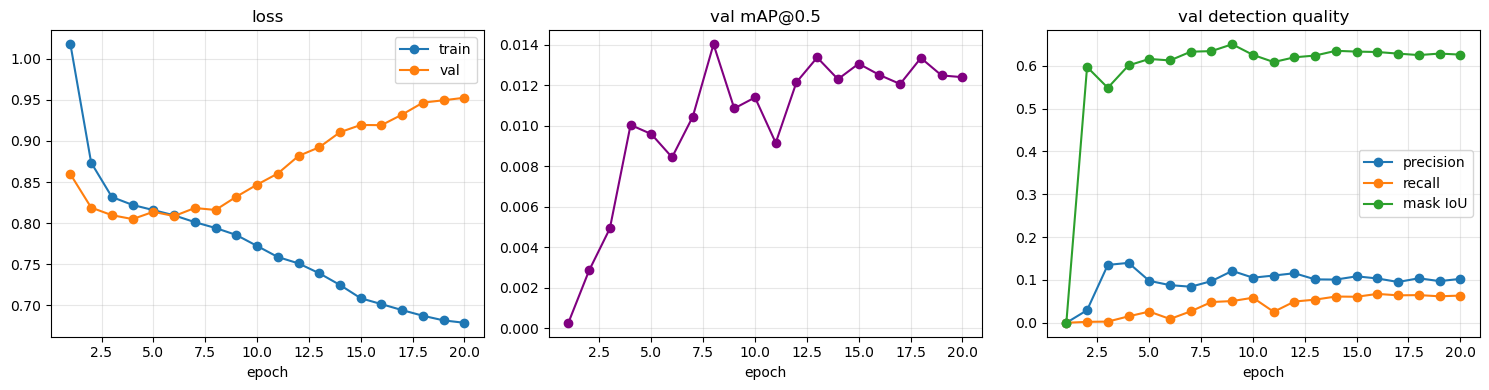

In [20]:
#  Plot + save training curves

history_path = OUTPUT_DIR / 'training_history.csv'
if 'hist_df' not in globals():
    if not history_path.exists():
        raise FileNotFoundError(f'training_history.csv not found at {history_path}')
    hist_df = pd.read_csv(history_path)
    print('Loaded training history from', history_path)

if hist_df.empty:
    raise ValueError('Training history is empty; run training or check training_history.csv.')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist_df.epoch, hist_df.train_loss, '-o', label='train')
axes[0].plot(hist_df.epoch, hist_df.val_loss, '-o', label='val')
axes[0].set_title('loss'); axes[0].set_xlabel('epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_df.epoch, hist_df['mAP@0.5'], '-o', color='purple')
axes[1].set_title('val mAP@0.5'); axes[1].set_xlabel('epoch'); axes[1].grid(alpha=0.3)

axes[2].plot(hist_df.epoch, hist_df.precision, '-o', label='precision')
axes[2].plot(hist_df.epoch, hist_df.recall, '-o', label='recall')
axes[2].plot(hist_df.epoch, hist_df.mean_mask_iou, '-o', label='mask IoU')
axes[2].set_title('val detection quality'); axes[2].set_xlabel('epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'training_curves.png', dpi=130, bbox_inches='tight')
plt.show()


## 12. Final evaluation (best checkpoint) + save `metrics.json`


In [ ]:
# Load best checkpoint and report final metrics

ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")

final_metrics = evaluate(model, val_loader, CFG)
scalar = {k: (round(v, 4) if isinstance(v, float) else v)
          for k, v in final_metrics.items() if not isinstance(v, dict)}
print(json.dumps(scalar, indent=2))
print('AP per class:', {k: round(v, 4) for k, v in final_metrics['AP_per_class'].items()})

(OUTPUT_DIR / 'metrics.json').write_text(json.dumps(final_metrics, indent=2))
print('Saved ->', OUTPUT_DIR / 'metrics.json')


Loaded best checkpoint from epoch 8


## 12a. Confusion matrix sanity check

Run this tiny cell first. If it does not print immediately, Jupyter is not executing the updated notebook or the kernel is busy.


In [24]:
# Tiny sanity check before the full confusion-matrix run
print('SANITY CHECK: this notebook cell is running.', flush=True)
print('If you see this, run the next confusion matrix cell.', flush=True)
print('Expected full validation batches:', len(val_loader) if 'val_loader' in globals() else 'val_loader not loaded', flush=True)


SANITY CHECK: this notebook cell is running.
If you see this, run the next confusion matrix cell.
Expected full validation batches: 853


## 12b. Best-model confusion matrix

Detection confusion matrix on the validation split. Rows are ground-truth labels and columns are predicted labels; `background` in a row means false positives, and `background` in a column means missed ground-truth objects.


CONFUSION MATRIX CELL IS EXECUTING...
Validation batches to process: 853/853
IoU threshold=0.50 | score threshold=0.50
  confusion matrix batches: 1/853
  confusion matrix batches: 25/853
  confusion matrix batches: 50/853
  confusion matrix batches: 75/853
  confusion matrix batches: 100/853
  confusion matrix batches: 125/853
  confusion matrix batches: 150/853
  confusion matrix batches: 175/853
  confusion matrix batches: 200/853
  confusion matrix batches: 225/853
  confusion matrix batches: 250/853
  confusion matrix batches: 275/853
  confusion matrix batches: 300/853
  confusion matrix batches: 325/853
  confusion matrix batches: 350/853
  confusion matrix batches: 375/853
  confusion matrix batches: 400/853
  confusion matrix batches: 425/853
  confusion matrix batches: 450/853
  confusion matrix batches: 475/853
  confusion matrix batches: 500/853
  confusion matrix batches: 525/853
  confusion matrix batches: 550/853
  confusion matrix batches: 575/853
  confusion matrix bat

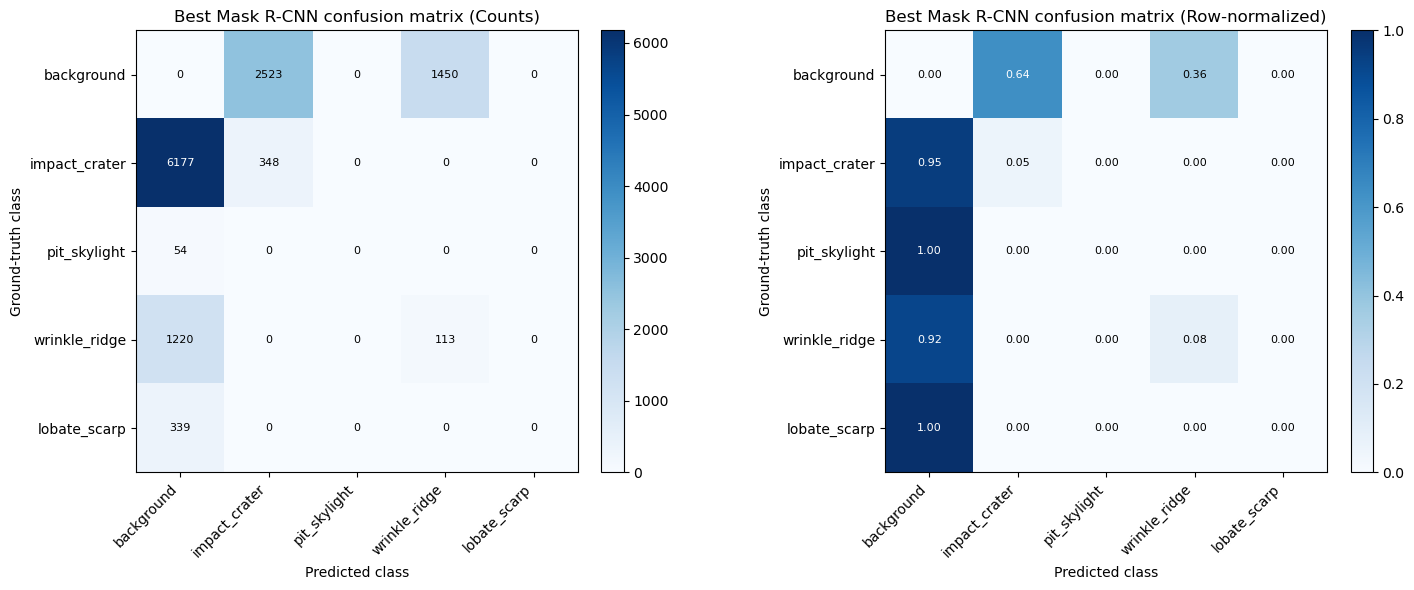

Saved confusion matrix -> /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/figures/best_model_confusion_matrix.png
Saved counts CSV       -> /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/best_model_confusion_matrix.csv
Saved normalized CSV   -> /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/best_model_confusion_matrix_row_normalized.csv


,background,impact_crater,pit_skylight,wrinkle_ridge,lobate_scarp
background,0,2523,0,1450,0
impact_crater,6177,348,0,0,0
pit_skylight,54,0,0,0,0
wrinkle_ridge,1220,0,0,113,0
lobate_scarp,339,0,0,0,0


In [25]:
# Confusion matrix for best_model.pth on the validation split
# Rows = ground truth, columns = prediction. Background column = missed objects; background row = false positives.

print('CONFUSION MATRIX CELL IS EXECUTING...', flush=True)


_required = ['model', 'val_loader', 'CFG', 'NUM_CLASSES', 'CLASS_NAMES', 'DEVICE', 'pairwise_mask_iou']
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError('Run setup, validation split, model, best checkpoint, and metric cells first. Missing: ' + ', '.join(_missing))

CONFUSION_IOU_THRESHOLD = CFG.eval_iou_thresh
CONFUSION_SCORE_THRESHOLD = CFG.score_thresh_eval
CONFUSION_MASK_THRESHOLD = CFG.mask_thresh
CONFUSION_MAX_BATCHES = None  # FULL validation split. Use 20 only for a quick debug test.

_total_confusion_batches = len(val_loader) if hasattr(val_loader, '__len__') else '?'
_planned_confusion_batches = (_total_confusion_batches if CONFUSION_MAX_BATCHES is None
                              else min(CONFUSION_MAX_BATCHES, _total_confusion_batches))

print(f'Validation batches to process: {_planned_confusion_batches}/{_total_confusion_batches}', flush=True)
print(f'IoU threshold={CONFUSION_IOU_THRESHOLD:.2f} | score threshold={CONFUSION_SCORE_THRESHOLD:.2f}', flush=True)

@torch.no_grad()
def compute_detection_confusion_matrix(model, loader, cfg=CFG,
                                       score_threshold=CONFUSION_SCORE_THRESHOLD,
                                       iou_threshold=CONFUSION_IOU_THRESHOLD,
                                       mask_threshold=CONFUSION_MASK_THRESHOLD,
                                       max_batches=CONFUSION_MAX_BATCHES):
    model.eval()
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    for bi, (images, targets) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        preds = model([im.to(DEVICE) for im in images])

        for pred, tgt in zip(preds, targets):
            p_scores = pred['scores'].detach().cpu().numpy()
            keep = p_scores >= float(score_threshold)
            p_scores = p_scores[keep]
            p_labels = pred['labels'].detach().cpu().numpy().astype(np.int64)[keep]
            p_boxes = pred['boxes'].detach().cpu().numpy().astype(np.float32)[keep]
            p_masks = pred['masks'].detach().cpu().numpy()
            if p_masks.ndim == 4:
                p_masks = p_masks[:, 0]
            p_masks = (p_masks >= mask_threshold).astype(np.uint8)[keep]

            g_labels = tgt['labels'].detach().cpu().numpy().astype(np.int64)
            g_boxes = tgt['boxes'].detach().cpu().numpy().astype(np.float32)
            g_masks = tgt['masks'].detach().cpu().numpy().astype(np.uint8)

            matched_p, matched_g = set(), set()
            if len(p_masks) and len(g_masks):
                iou_matrix = pairwise_mask_iou(p_masks, p_boxes, g_masks, g_boxes)
                candidate_pairs = sorted(
                    [(float(iou_matrix[pi, gi]), pi, gi)
                     for pi in range(len(p_masks)) for gi in range(len(g_masks))
                     if iou_matrix[pi, gi] >= iou_threshold],
                    reverse=True,
                )
                for _, pi, gi in candidate_pairs:
                    if pi in matched_p or gi in matched_g:
                        continue
                    matched_p.add(pi)
                    matched_g.add(gi)
                    true_label = int(g_labels[gi])
                    pred_label = int(p_labels[pi])
                    if 0 <= true_label < NUM_CLASSES and 0 <= pred_label < NUM_CLASSES:
                        cm[true_label, pred_label] += 1

            # Ground-truth objects that were not matched are false negatives.
            for gi, true_label in enumerate(g_labels):
                if gi not in matched_g and 0 <= int(true_label) < NUM_CLASSES:
                    cm[int(true_label), 0] += 1

            # Predictions that were not matched are false positives.
            for pi, pred_label in enumerate(p_labels):
                if pi not in matched_p and 0 <= int(pred_label) < NUM_CLASSES:
                    cm[0, int(pred_label)] += 1

        if bi == 0 or (bi + 1) % 25 == 0 or (hasattr(loader, '__len__') and (bi + 1) == len(loader)):
            done = bi + 1
            total = len(loader) if hasattr(loader, '__len__') else '?'
            print(f'  confusion matrix batches: {done}/{total}', flush=True)

    return cm

confusion_counts = compute_detection_confusion_matrix(model, val_loader)
confusion_df = pd.DataFrame(confusion_counts, index=CLASS_NAMES, columns=CLASS_NAMES)

row_totals = confusion_counts.sum(axis=1, keepdims=True)
confusion_normalized = np.divide(
    confusion_counts,
    np.maximum(row_totals, 1),
    out=np.zeros_like(confusion_counts, dtype=np.float64),
    where=row_totals > 0,
)
confusion_norm_df = pd.DataFrame(confusion_normalized, index=CLASS_NAMES, columns=CLASS_NAMES)

confusion_csv = OUTPUT_DIR / 'best_model_confusion_matrix.csv'
confusion_norm_csv = OUTPUT_DIR / 'best_model_confusion_matrix_row_normalized.csv'
confusion_png = OUTPUT_DIR / 'figures' / 'best_model_confusion_matrix.png'
confusion_df.to_csv(confusion_csv)
confusion_norm_df.to_csv(confusion_norm_csv)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, data, title, fmt in [
    (axes[0], confusion_counts, 'Counts', 'd'),
    (axes[1], confusion_normalized, 'Row-normalized', '.2f'),
]:
    im = ax.imshow(data, cmap='Blues')
    ax.set_title(f'Best Mask R-CNN confusion matrix ({title})')
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('Ground-truth class')
    ax.set_xticks(np.arange(NUM_CLASSES))
    ax.set_yticks(np.arange(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    max_value = float(np.max(data)) if np.size(data) else 0.0
    threshold = max_value * 0.55
    for r in range(NUM_CLASSES):
        for c in range(NUM_CLASSES):
            value = data[r, c]
            text = format(int(value), fmt) if fmt == 'd' else format(float(value), fmt)
            ax.text(c, r, text, ha='center', va='center',
                    color='white' if value > threshold else 'black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
fig.savefig(confusion_png, dpi=160, bbox_inches='tight')
plt.show()

print('Saved confusion matrix ->', confusion_png)
print('Saved counts CSV       ->', confusion_csv)
print('Saved normalized CSV   ->', confusion_norm_csv)
confusion_df


## 13. Qualitative comparison - original, ground truth, and prediction


## Qualitative Prediction Samples

![10 best-model prediction samples](figures/best_model_10_prediction_samples_display.jpg)



## 13b. Reusable best-model prediction helper

This helper runs the loaded `best_model.pth` detector on any image tensor and returns NumPy arrays that can be saved or plotted.


In [14]:
# Best-model inference helper used by validation exports and PNG test tiles

@torch.no_grad()
def predict_image_tensor(model, image_chw, score_threshold=None, mask_threshold=None):
    if score_threshold is None:
        score_threshold = CFG.score_thresh_eval
    if mask_threshold is None:
        mask_threshold = CFG.mask_thresh

    model.eval()
    if not torch.is_tensor(image_chw):
        image_chw = torch.as_tensor(normalize_image_chw(image_chw), dtype=torch.float32)
    else:
        image_chw = image_chw.detach().to(dtype=torch.float32).cpu()

    pred = model([image_chw.to(DEVICE)])[0]
    boxes = pred['boxes'].detach().cpu().numpy().astype(np.float32)
    labels = pred['labels'].detach().cpu().numpy().astype(np.int64)
    scores = pred['scores'].detach().cpu().numpy().astype(np.float32)
    masks = pred['masks'].detach().cpu().numpy()
    if masks.ndim == 4:
        masks = masks[:, 0]
    masks = (masks >= mask_threshold).astype(np.uint8)

    if score_threshold is not None:
        keep = scores >= float(score_threshold)
        boxes, labels, scores, masks = boxes[keep], labels[keep], scores[keep], masks[keep]

    return {'boxes': boxes, 'labels': labels, 'scores': scores, 'masks': masks}

# Backward-compatible name used by the validation export cell.
def predict_tile(model, image_chw, score_threshold=None, mask_threshold=None):
    return predict_image_tensor(model, image_chw, score_threshold, mask_threshold)

print('Prediction helper ready | score threshold:', CFG.score_thresh_eval,
      '| mask threshold:', CFG.mask_thresh)


Prediction helper ready | score threshold: 0.5 | mask threshold: 0.5


## 14. Save validation predictions

For every validation tile we save predicted instance masks, boxes, labels, and confidence scores to `predictions/`, plus a JSON summary.


In [21]:
# Export validation-set predictions + summary

n_export = len(val_ds) if CFG.max_pred_export is None else min(CFG.max_pred_export, len(val_ds))
summary = []
for i in range(n_export):
    img, tgt = val_ds[i]
    pred = predict_tile(model, img)
    name = Path(val_ds.files[i]).stem
    np.savez_compressed(OUTPUT_DIR / 'predictions' / f'{name}_pred.npz',
                        boxes=pred['boxes'], labels=pred['labels'],
                        scores=pred['scores'], masks=pred['masks'])
    summary.append({'tile': name,
                    'n_pred': int(len(pred['boxes'])),
                    'n_gt': int(len(tgt['boxes'])),
                    'pred_labels': [int(x) for x in pred['labels']],
                    'pred_scores': [round(float(s), 4) for s in pred['scores']]})

(OUTPUT_DIR / 'predictions_summary.json').write_text(json.dumps(summary, indent=2))
print(f'Saved {len(summary)} validation prediction files to {OUTPUT_DIR / "predictions"}')


Saved 500 validation prediction files to /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/predictions


## 15. Apply `best_model.pth` to PNG test tiles

This section reads the `tiles/` folder, applies the loaded Mask R-CNN checkpoint to every test image, saves per-tile prediction files, and creates a 10-sample prediction figure.


Found 3639 test tiles in /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/tiles
Running inference on 3639 tile(s) with score >= 0.50
  processed    1/3639 tiles
  processed  100/3639 tiles
  processed  200/3639 tiles
  processed  300/3639 tiles
  processed  400/3639 tiles
  processed  500/3639 tiles
  processed  600/3639 tiles
  processed  700/3639 tiles
  processed  800/3639 tiles
  processed  900/3639 tiles
  processed 1000/3639 tiles
  processed 1100/3639 tiles
  processed 1200/3639 tiles
  processed 1300/3639 tiles
  processed 1400/3639 tiles
  processed 1500/3639 tiles
  processed 1600/3639 tiles
  processed 1700/3639 tiles
  processed 1800/3639 tiles
  processed 1900/3639 tiles
  processed 2000/3639 tiles
  processed 2100/3639 tiles
  processed 2200/3639 tiles
  processed 2300/3639 tiles
  processed 2400/3639 tiles
  processed 2500/3639 tiles
  processed 2600/3639 tiles
  processed 2700/3639 tiles
  processed 2800/3639 tiles
  processed 2900/3639 tiles
  processed 3000/36

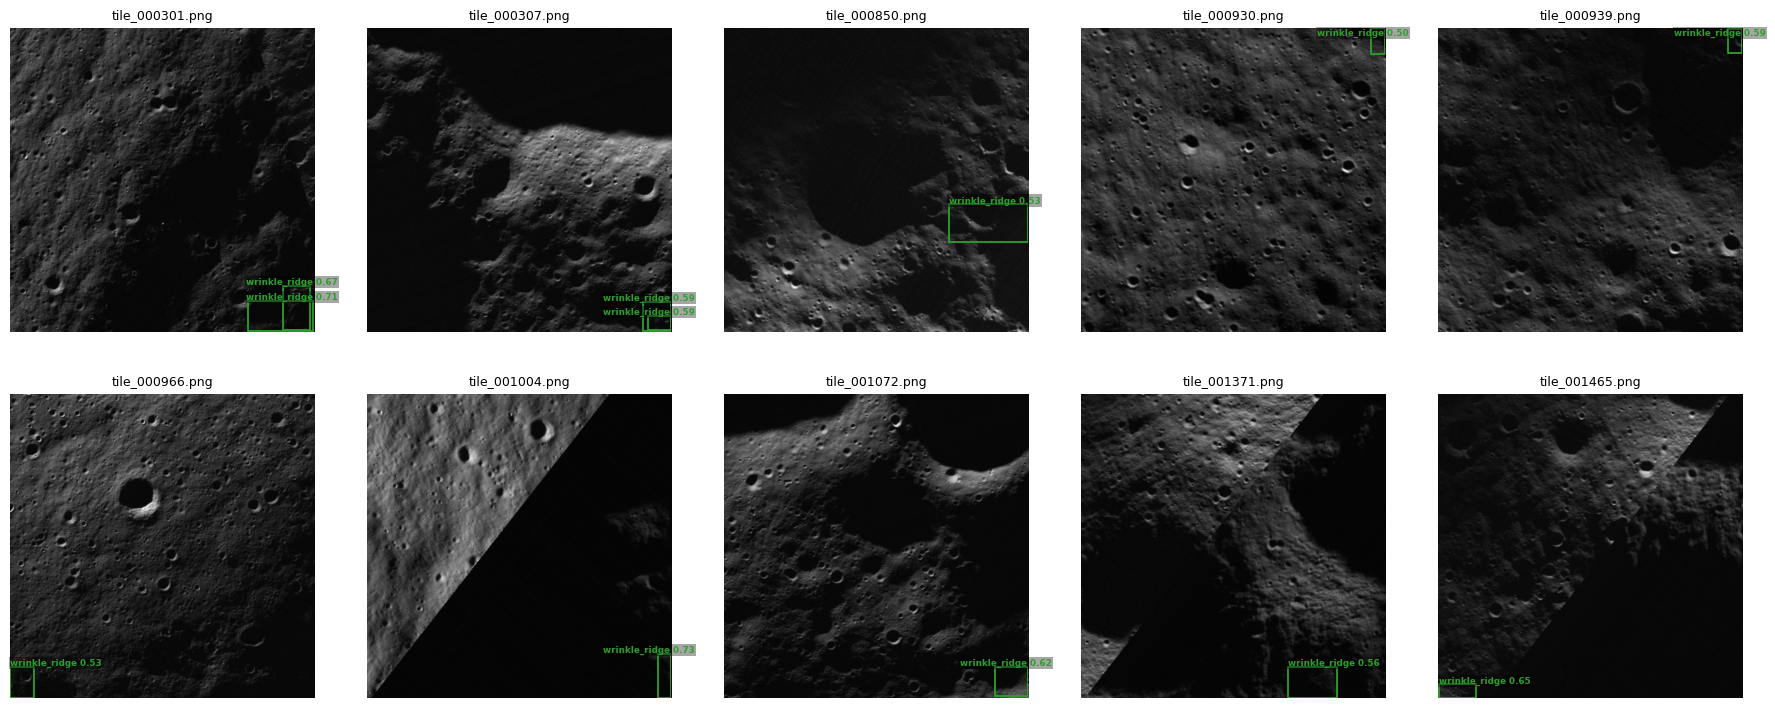

Saved 10-sample figure -> /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/figures/best_model_10_tile_samples.png


In [22]:
# Apply the best model to PNG/JPG/TIF test tiles and save 10 visual samples
from PIL import Image

TEST_TILE_DIR_CANDIDATES = [
    Path.cwd() / 'tiles',
    OUTPUT_DIR / 'tiles',
    Path.home() / 'Desktop' / 'amir_rcnn_outputs' / 'tiles',
]
TEST_TILE_DIR = next((p for p in TEST_TILE_DIR_CANDIDATES if p.exists()), None)
if TEST_TILE_DIR is None:
    checked = '\n'.join(str(p) for p in TEST_TILE_DIR_CANDIDATES)
    raise FileNotFoundError('Could not find the test tiles folder. Checked:\n' + checked)

TEST_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
TEST_SCORE_THRESHOLD = CFG.score_thresh_eval
TEST_MASK_THRESHOLD = CFG.mask_thresh
MAX_TEST_TILES = None  # None = run the full tiles folder; set an integer for a quick dry run.
SAMPLE_COUNT = 10

TILE_PRED_DIR = OUTPUT_DIR / 'tile_predictions'
TILE_PRED_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)

test_image_paths = sorted(p for p in TEST_TILE_DIR.iterdir()
                          if p.is_file() and p.suffix.lower() in TEST_EXTENSIONS)
if not test_image_paths:
    raise FileNotFoundError(f'No image tiles found in {TEST_TILE_DIR}')
run_paths = test_image_paths if MAX_TEST_TILES is None else test_image_paths[:MAX_TEST_TILES]
print(f'Found {len(test_image_paths)} test tiles in {TEST_TILE_DIR}')
print(f'Running inference on {len(run_paths)} tile(s) with score >= {TEST_SCORE_THRESHOLD:.2f}')

CLASS_NAMES_FROM_CKPT = ckpt.get('class_names', CLASS_NAMES) if 'ckpt' in globals() else CLASS_NAMES
LABEL_TO_NAME_TEST = {i: name for i, name in enumerate(CLASS_NAMES_FROM_CKPT)}

def load_test_tile(path):
    with Image.open(path) as im:
        image = np.asarray(im.convert('RGB'), dtype=np.float32) / 255.0
    image = np.moveaxis(image, -1, 0)
    return torch.as_tensor(image, dtype=torch.float32)

def prediction_label_counts(labels):
    counts = {}
    for label in labels:
        name = LABEL_TO_NAME_TEST.get(int(label), str(int(label)))
        counts[name] = counts.get(name, 0) + 1
    return counts

def plot_test_prediction(image_chw, pred, title, ax=None):
    image_hwc = np.moveaxis(normalize_image_chw(image_chw), 0, -1)
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_hwc)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

    boxes = pred['boxes']
    labels = pred['labels']
    scores = pred['scores']
    masks = pred['masks']
    for i, box in enumerate(boxes):
        lab = int(labels[i]) if i < len(labels) else 1
        label_text = LABEL_TO_NAME_TEST.get(lab, str(lab))
        color = class_color(lab)
        if i < len(masks) and label_text != 'wrinkle_ridge':
            m = masks[i].astype(bool)
            overlay = np.zeros((m.shape[0], m.shape[1], 4), dtype=np.float32)
            overlay[m] = (color[0], color[1], color[2], 0.35)
            ax.imshow(overlay)
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, lw=1.3, edgecolor=color))
        text = f'{label_text} {scores[i]:.2f}'
        h, w = image_hwc.shape[:2]
        tx = min(max(0, float(x1)), max(0, w - 115))
        ty = float(y1 - 2) if y1 >= 12 else float(y1 + 12)
        ty = min(max(8, ty), h - 4)
        ax.text(tx, ty, text, color=color, fontsize=6.3, weight='bold',
                bbox={'facecolor': 'black', 'alpha': 0.35, 'edgecolor': 'none', 'pad': 1.0})
    if own:
        plt.tight_layout()
        plt.show()

summary = []
positive_preview = []
fallback_preview = []

for i, path in enumerate(run_paths, start=1):
    image = load_test_tile(path)
    pred = predict_image_tensor(model, image,
                                score_threshold=TEST_SCORE_THRESHOLD,
                                mask_threshold=TEST_MASK_THRESHOLD)
    out_path = TILE_PRED_DIR / f'{path.stem}_pred.npz'
    np.savez_compressed(out_path,
                        boxes=pred['boxes'], labels=pred['labels'],
                        scores=pred['scores'], masks=pred['masks'],
                        image_size=np.array(image.shape[-2:], dtype=np.int32))

    record = {
        'tile': path.name,
        'prediction_file': str(out_path.relative_to(OUTPUT_DIR)),
        'image_size': [int(image.shape[-2]), int(image.shape[-1])],
        'n_pred': int(len(pred['boxes'])),
        'label_counts': prediction_label_counts(pred['labels']),
        'pred_labels': [int(x) for x in pred['labels']],
        'pred_scores': [round(float(s), 4) for s in pred['scores']],
    }
    summary.append(record)

    preview_item = (path, image.cpu().numpy(), pred)
    if len(fallback_preview) < SAMPLE_COUNT:
        fallback_preview.append(preview_item)
    if len(pred['boxes']) > 0 and len(positive_preview) < SAMPLE_COUNT:
        positive_preview.append(preview_item)

    if i == 1 or i % 100 == 0 or i == len(run_paths):
        print(f'  processed {i:>4}/{len(run_paths)} tiles')

summary_path = OUTPUT_DIR / 'tile_predictions_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Saved {len(summary)} test prediction files to {TILE_PRED_DIR}')
print(f'Saved summary to {summary_path}')

preview = positive_preview[:SAMPLE_COUNT]
seen_names = {p.name for p, _, _ in preview}
for item in fallback_preview:
    if len(preview) >= SAMPLE_COUNT:
        break
    if item[0].name not in seen_names:
        preview.append(item)
        seen_names.add(item[0].name)

if preview:
    n_cols = 5
    n_rows = math.ceil(len(preview) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.8 * n_rows))
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, (path, image, pred) in zip(axes.ravel(), preview):
        plot_test_prediction(image, pred, path.name, ax=ax)
    plt.tight_layout()
    sample_png = OUTPUT_DIR / 'figures' / 'best_model_10_tile_samples.png'
    sample_jpg = OUTPUT_DIR / 'figures' / 'best_model_10_tile_samples.jpg'
    fig.savefig(sample_png, dpi=160, bbox_inches='tight')
    fig.savefig(sample_jpg, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved 10-sample figure ->', sample_png)
else:
    print('No preview images were available to plot.')


## 16. Test-tile feature proportions

This pie chart summarizes the best-model predictions on the 3,639 PNG test tiles. Because these test images do not include ground-truth masks, the proportions are model-predicted feature proportions at the chosen confidence threshold.


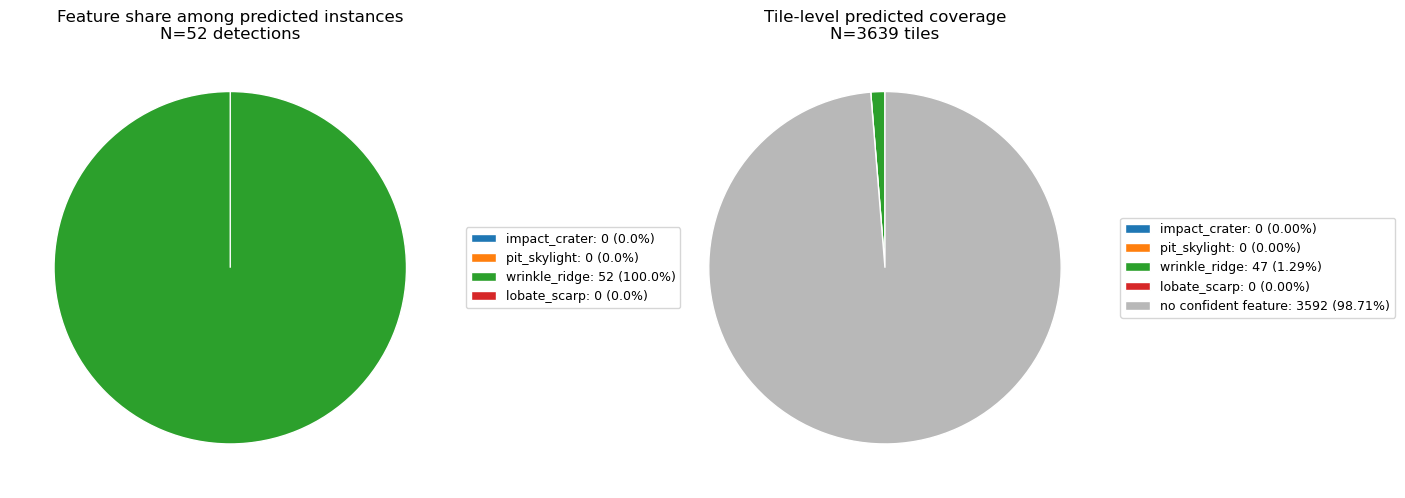

Saved pie chart -> /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/figures/test_tile_feature_proportions_pie.png
Saved table     -> /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/tile_feature_proportions.csv


,feature,predicted_instances,instance_share_percent,tiles_with_feature,tile_share_percent,dominant_feature_tiles
0,impact_crater,0,0.0,0,0.0000,0
1,pit_skylight,0,0.0,0,0.0000,0
2,wrinkle_ridge,52,100.0,47,1.2916,47
3,lobate_scarp,0,0.0,0,0.0000,0


In [23]:
# Pie charts for predicted proportions of the four lunar features in the PNG test tiles

feature_summary_path = OUTPUT_DIR / 'tile_predictions_summary.json'
if not feature_summary_path.exists():
    raise FileNotFoundError(
        f'{feature_summary_path} not found. Run the PNG test-tile inference section first.'
    )

tile_prediction_summary = json.loads(feature_summary_path.read_text())
n_test_tiles = len(tile_prediction_summary)

if 'CLASS_NAMES_FROM_CKPT' in globals():
    feature_names = list(CLASS_NAMES_FROM_CKPT[1:])
elif 'ckpt' in globals() and isinstance(ckpt, dict) and 'class_names' in ckpt:
    feature_names = list(ckpt['class_names'][1:])
else:
    feature_names = list(CLASS_NAMES[1:])
feature_names = feature_names[:4]

instance_counts = {name: 0 for name in feature_names}
tile_presence_counts = {name: 0 for name in feature_names}
dominant_tile_counts = {name: 0 for name in feature_names}
positive_tiles = 0

for record in tile_prediction_summary:
    label_counts = {name: int(record.get('label_counts', {}).get(name, 0))
                    for name in feature_names}
    n_pred = sum(label_counts.values())
    if n_pred > 0:
        positive_tiles += 1
        dominant_feature = max(label_counts, key=lambda name: label_counts[name])
        dominant_tile_counts[dominant_feature] += 1
    for name, count in label_counts.items():
        instance_counts[name] += count
        if count > 0:
            tile_presence_counts[name] += 1

feature_rows = []
total_instances = sum(instance_counts.values())
for name in feature_names:
    feature_rows.append({
        'feature': name,
        'predicted_instances': int(instance_counts[name]),
        'instance_share_percent': round((instance_counts[name] / total_instances * 100) if total_instances else 0.0, 4),
        'tiles_with_feature': int(tile_presence_counts[name]),
        'tile_share_percent': round((tile_presence_counts[name] / n_test_tiles * 100) if n_test_tiles else 0.0, 4),
        'dominant_feature_tiles': int(dominant_tile_counts[name]),
    })

feature_proportions = {
    'n_test_tiles': int(n_test_tiles),
    'score_threshold': float(TEST_SCORE_THRESHOLD) if 'TEST_SCORE_THRESHOLD' in globals() else float(CFG.score_thresh_eval),
    'mask_threshold': float(TEST_MASK_THRESHOLD) if 'TEST_MASK_THRESHOLD' in globals() else float(CFG.mask_thresh),
    'positive_tiles': int(positive_tiles),
    'no_confident_feature_tiles': int(n_test_tiles - positive_tiles),
    'total_predicted_instances': int(total_instances),
    'features': feature_rows,
}

proportions_json = OUTPUT_DIR / 'tile_feature_proportions.json'
proportions_csv = OUTPUT_DIR / 'tile_feature_proportions.csv'
proportions_json.write_text(json.dumps(feature_proportions, indent=2))
pd.DataFrame(feature_rows).to_csv(proportions_csv, index=False)

colors = [class_color(i + 1) for i in range(len(feature_names))]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

instance_values = [instance_counts[name] for name in feature_names]
if total_instances > 0:
    wedges, _ = axes[0].pie(instance_values, startangle=90, colors=colors,
                            wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
    axes[0].legend(
        wedges,
        [f'{name}: {instance_counts[name]} ({(instance_counts[name] / total_instances * 100):.1f}%)'
         for name in feature_names],
        loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9,
    )
else:
    axes[0].text(0.5, 0.5, 'No predictions', ha='center', va='center')
axes[0].set_title(f'Feature share among predicted instances\nN={total_instances} detections')

coverage_labels = feature_names + ['no confident feature']
coverage_values = [dominant_tile_counts[name] for name in feature_names] + [n_test_tiles - positive_tiles]
coverage_colors = colors + [(0.72, 0.72, 0.72)]
wedges, _ = axes[1].pie(coverage_values, startangle=90, colors=coverage_colors,
                        wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
axes[1].legend(
    wedges,
    [f'{label}: {value} ({(value / n_test_tiles * 100):.2f}%)'
     for label, value in zip(coverage_labels, coverage_values)],
    loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9,
)
axes[1].set_title(f'Tile-level predicted coverage\nN={n_test_tiles} tiles')

plt.tight_layout()
pie_png = OUTPUT_DIR / 'figures' / 'test_tile_feature_proportions_pie.png'
pie_jpg = OUTPUT_DIR / 'figures' / 'test_tile_feature_proportions_pie.jpg'
fig.savefig(pie_png, dpi=160, bbox_inches='tight')
fig.savefig(pie_jpg, dpi=160, bbox_inches='tight')
plt.show()

print('Saved pie chart ->', pie_png)
print('Saved table     ->', proportions_csv)
pd.DataFrame(feature_rows)


## 17. Low-threshold crater search on PNG test tiles

This section reruns the loaded best Mask R-CNN at a lower confidence threshold and searches specifically for `impact_crater` detections. If crater candidates exist, it saves a JSON summary and a 10-sample figure.


Low-threshold crater search: 3639 tiles from /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/tiles
Target=impact_crater | thresholds=[0.5, 0.2, 0.1, 0.05]
  processed    1/3639 | 2.97 tiles/s | crater@0.10 tiles=0
  processed  100/3639 | 2.11 tiles/s | crater@0.10 tiles=38
  processed  200/3639 | 2.47 tiles/s | crater@0.10 tiles=63
  processed  300/3639 | 2.72 tiles/s | crater@0.10 tiles=79
  processed  400/3639 | 2.90 tiles/s | crater@0.10 tiles=93
  processed  500/3639 | 2.70 tiles/s | crater@0.10 tiles=118
  processed  600/3639 | 2.66 tiles/s | crater@0.10 tiles=131
  processed  700/3639 | 2.63 tiles/s | crater@0.10 tiles=155
  processed  800/3639 | 2.51 tiles/s | crater@0.10 tiles=184
  processed  900/3639 | 2.46 tiles/s | crater@0.10 tiles=212
  processed 1000/3639 | 2.45 tiles/s | crater@0.10 tiles=236
  processed 1100/3639 | 2.43 tiles/s | crater@0.10 tiles=261
  processed 1200/3639 | 2.40 tiles/s | crater@0.10 tiles=285
  processed 1300/3639 | 2.39 tiles/s | crater@0.1

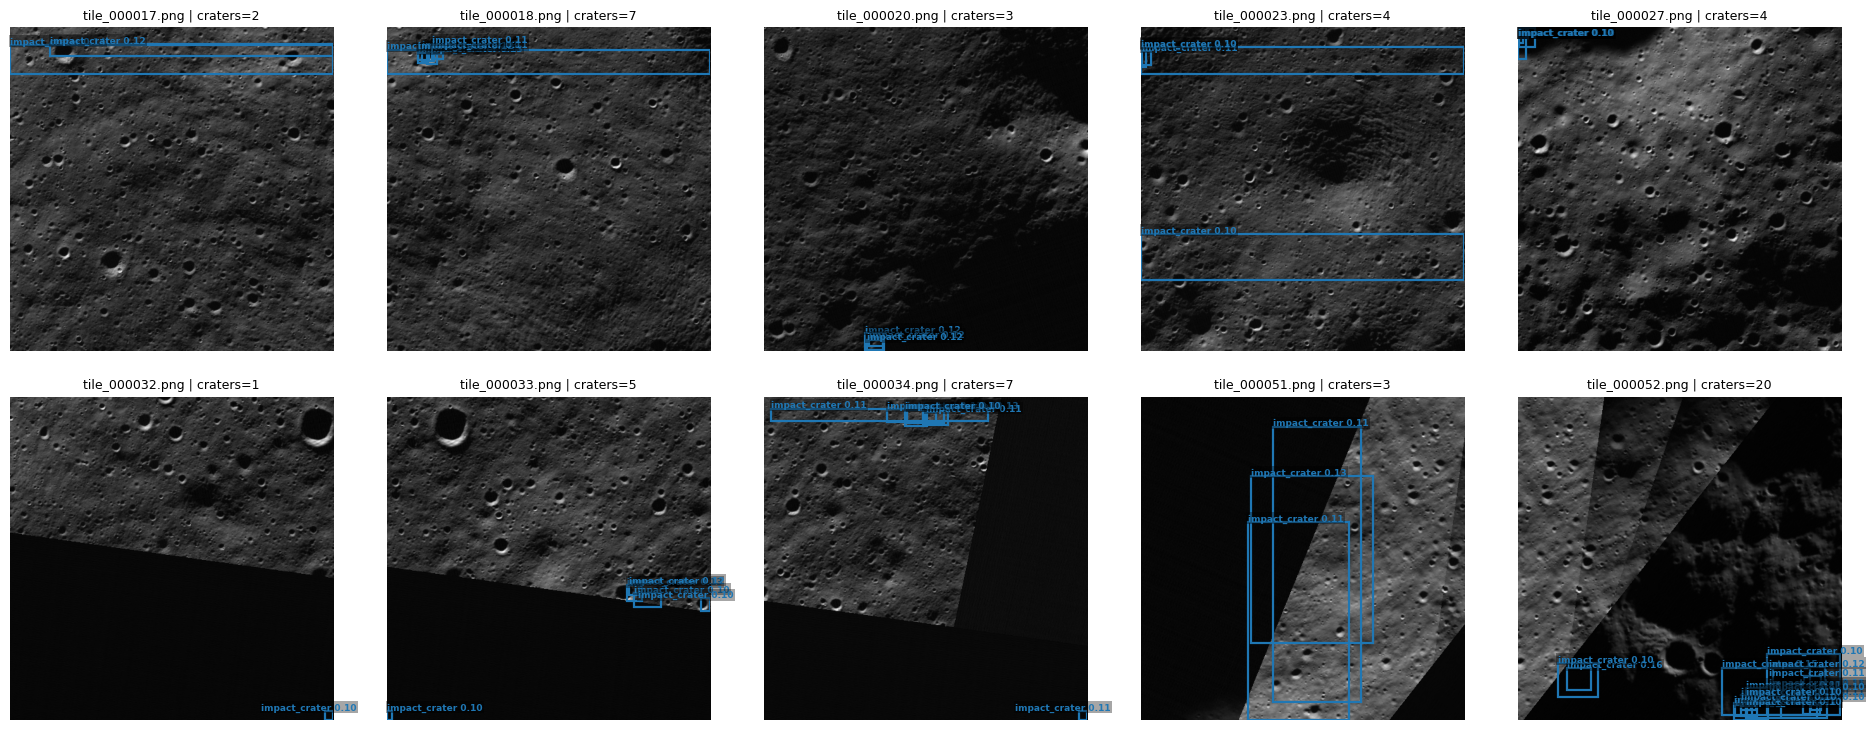

Saved crater sample figure -> /Users/amirmohammadsaiedisaber/Desktop/amir_rcnn_outputs/figures/low_threshold_crater_candidate_samples.png


,threshold,tiles_with_crater,crater_detections
0,0.50,0,0
1,0.20,78,188
2,0.10,1054,8176
3,0.05,2066,104871


In [27]:
# Low-threshold crater search on PNG/JPG/TIF test tiles
# Run after loading best_model.pth and after the reusable prediction helper cell.
from PIL import Image

LOW_TEST_SCORE_THRESHOLDS = [0.50, 0.20, 0.10, 0.05]
LOW_SAMPLE_THRESHOLD = 0.10
LOW_TEST_MASK_THRESHOLD = CFG.mask_thresh
TARGET_FEATURE = 'impact_crater'
LOW_MAX_TEST_TILES = None  # None = scan all test tiles
LOW_SAMPLE_COUNT = 10

_required = ['model', 'OUTPUT_DIR', 'CFG']
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError('Run setup/model/best-checkpoint cells first. Missing: ' + ', '.join(_missing))

TEST_TILE_DIR_CANDIDATES = [
    Path.cwd() / 'tiles',
    OUTPUT_DIR / 'tiles',
    Path.home() / 'Desktop' / 'amir_rcnn_outputs' / 'tiles',
]
TEST_TILE_DIR = next((p for p in TEST_TILE_DIR_CANDIDATES if p.exists()), None)
if TEST_TILE_DIR is None:
    checked = '\n'.join(str(p) for p in TEST_TILE_DIR_CANDIDATES)
    raise FileNotFoundError('Could not find the test tiles folder. Checked:\n' + checked)

LOW_TEST_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}
low_test_image_paths = sorted(p for p in TEST_TILE_DIR.iterdir()
                              if p.is_file() and p.suffix.lower() in LOW_TEST_EXTENSIONS)
if LOW_MAX_TEST_TILES is not None:
    low_test_image_paths = low_test_image_paths[:LOW_MAX_TEST_TILES]
if not low_test_image_paths:
    raise FileNotFoundError(f'No image tiles found in {TEST_TILE_DIR}')

if 'CLASS_NAMES_FROM_CKPT' in globals():
    low_class_names = list(CLASS_NAMES_FROM_CKPT)
elif 'ckpt' in globals() and isinstance(ckpt, dict) and 'class_names' in ckpt:
    low_class_names = list(ckpt['class_names'])
else:
    low_class_names = list(CLASS_NAMES)
LOW_LABEL_TO_NAME = {i: name for i, name in enumerate(low_class_names)}
LOW_NAME_TO_LABEL = {name: i for i, name in LOW_LABEL_TO_NAME.items()}
if TARGET_FEATURE not in LOW_NAME_TO_LABEL:
    raise ValueError(f'{TARGET_FEATURE!r} is not in model classes: {low_class_names}')
TARGET_LABEL = LOW_NAME_TO_LABEL[TARGET_FEATURE]

def load_low_threshold_tile(path):
    with Image.open(path) as im:
        image = np.asarray(im.convert('RGB'), dtype=np.float32) / 255.0
    image = np.moveaxis(image, -1, 0)
    return torch.as_tensor(image, dtype=torch.float32)

@torch.no_grad()
def predict_raw_for_threshold_scan(model, image_chw, mask_threshold=LOW_TEST_MASK_THRESHOLD):
    model.eval()
    pred = model([image_chw.to(DEVICE)])[0]
    boxes = pred['boxes'].detach().cpu().numpy().astype(np.float32)
    labels = pred['labels'].detach().cpu().numpy().astype(np.int64)
    scores = pred['scores'].detach().cpu().numpy().astype(np.float32)
    masks = pred['masks'].detach().cpu().numpy()
    if masks.ndim == 4:
        masks = masks[:, 0]
    masks = (masks >= mask_threshold).astype(np.uint8)
    return {'boxes': boxes, 'labels': labels, 'scores': scores, 'masks': masks}

def select_prediction(pred, keep):
    return {key: value[keep] for key, value in pred.items()}

def plot_crater_candidates(image_chw, crater_pred, title, ax=None):
    image_hwc = np.moveaxis(normalize_image_chw(image_chw), 0, -1)
    own = ax is None
    if own:
        _, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_hwc)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

    h, w = image_hwc.shape[:2]
    for i, box in enumerate(crater_pred['boxes']):
        color = class_color(TARGET_LABEL)
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, lw=1.6, edgecolor=color))
        text = f'{TARGET_FEATURE} {crater_pred["scores"][i]:.2f}'
        tx = min(max(0, float(x1)), max(0, w - 115))
        ty = float(y1 - 2) if y1 >= 12 else float(y1 + 12)
        ty = min(max(8, ty), h - 4)
        ax.text(tx, ty, text, color=color, fontsize=6.5, weight='bold',
                bbox={'facecolor': 'black', 'alpha': 0.35, 'edgecolor': 'none', 'pad': 1.0})
    if own:
        plt.tight_layout()
        plt.show()


previous_score_thresh = model.roi_heads.score_thresh
model.roi_heads.score_thresh = min(LOW_TEST_SCORE_THRESHOLDS)

print(f'Low-threshold crater search: {len(low_test_image_paths)} tiles from {TEST_TILE_DIR}', flush=True)
print(f'Target={TARGET_FEATURE} | thresholds={LOW_TEST_SCORE_THRESHOLDS}', flush=True)

low_summary = []
crater_stats = {str(t): {'tiles_with_crater': 0, 'crater_detections': 0}
                for t in LOW_TEST_SCORE_THRESHOLDS}
crater_samples = []
t0 = time.time()

try:
    for i, path in enumerate(low_test_image_paths, start=1):
        image = load_low_threshold_tile(path)
        pred = predict_raw_for_threshold_scan(model, image)
        record = {'tile': path.name, 'thresholds': {}}

        for threshold in LOW_TEST_SCORE_THRESHOLDS:
            keep = (pred['labels'] == TARGET_LABEL) & (pred['scores'] >= threshold)
            scores = pred['scores'][keep]
            n_crater = int(len(scores))
            record['thresholds'][str(threshold)] = {
                'n_crater': n_crater,
                'scores': [round(float(s), 4) for s in scores],
            }
            if n_crater > 0:
                crater_stats[str(threshold)]['tiles_with_crater'] += 1
                crater_stats[str(threshold)]['crater_detections'] += n_crater

        sample_keep = (pred['labels'] == TARGET_LABEL) & (pred['scores'] >= LOW_SAMPLE_THRESHOLD)
        if sample_keep.any() and len(crater_samples) < LOW_SAMPLE_COUNT:
            crater_samples.append((path, image.cpu().numpy(), select_prediction(pred, sample_keep),
                                   record['thresholds'][str(LOW_SAMPLE_THRESHOLD)]['n_crater']))
        low_summary.append(record)

        if i == 1 or i % 100 == 0 or i == len(low_test_image_paths):
            elapsed = time.time() - t0
            rate = i / elapsed if elapsed else 0.0
            print(f'  processed {i:>4}/{len(low_test_image_paths)} | {rate:.2f} tiles/s | '
                  f'crater@{LOW_SAMPLE_THRESHOLD:.2f} tiles={crater_stats[str(LOW_SAMPLE_THRESHOLD)]["tiles_with_crater"]}',
                  flush=True)
finally:
    model.roi_heads.score_thresh = previous_score_thresh

low_summary_path = OUTPUT_DIR / 'low_threshold_crater_search_summary.json'
low_summary_path.write_text(json.dumps({
    'target_feature': TARGET_FEATURE,
    'target_label': int(TARGET_LABEL),
    'thresholds': LOW_TEST_SCORE_THRESHOLDS,
    'sample_threshold': float(LOW_SAMPLE_THRESHOLD),
    'mask_threshold': float(LOW_TEST_MASK_THRESHOLD),
    'n_tiles_scanned': int(len(low_test_image_paths)),
    'stats': crater_stats,
    'records': low_summary,
}, indent=2))
print('Saved low-threshold crater summary ->', low_summary_path, flush=True)
print(json.dumps(crater_stats, indent=2), flush=True)

if crater_samples:
    sample_items = crater_samples[:LOW_SAMPLE_COUNT]
    n_cols = min(5, len(sample_items))
    n_rows = math.ceil(len(sample_items) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.8 * n_cols, 3.8 * n_rows))
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)
    for ax in axes.ravel():
        ax.axis('off')
    for ax, (path, image, crater_pred, n_crater) in zip(axes.ravel(), sample_items):
        plot_crater_candidates(image, crater_pred, f'{path.name} | craters={n_crater}', ax=ax)
    plt.tight_layout()
    crater_png = OUTPUT_DIR / 'figures' / 'low_threshold_crater_candidate_samples.png'
    crater_jpg = OUTPUT_DIR / 'figures' / 'low_threshold_crater_candidate_samples.jpg'
    fig.savefig(crater_png, dpi=160, bbox_inches='tight')
    fig.savefig(crater_jpg, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved crater sample figure ->', crater_png, flush=True)
else:
    print(f'No {TARGET_FEATURE} candidates found at score >= {LOW_SAMPLE_THRESHOLD:.2f}.', flush=True)

pd.DataFrame([
    {'threshold': threshold, **crater_stats[str(threshold)]}
    for threshold in LOW_TEST_SCORE_THRESHOLDS
])
